In [1]:
import numpy as np
import uproot
import pandas as pd
import awkward as ak


In [2]:
file = uproot.open('crrc43ns.root')
tgraph = file["grCRRC43"]
x_values, y_values = tgraph.values()

signal_shapes = []
for i in range(16):
    signal_shapes.append(y_values[(180 + 25 * (i + 3) - 250)])
signal_shapes = np.array(signal_shapes)

presamples = np.zeros(3)
signal_shapes = np.concatenate((presamples, signal_shapes), axis = 0)

signal_shapes_10 = signal_shapes[0:10]  # save 1D 10-sample template slice before reshape in Cell 4

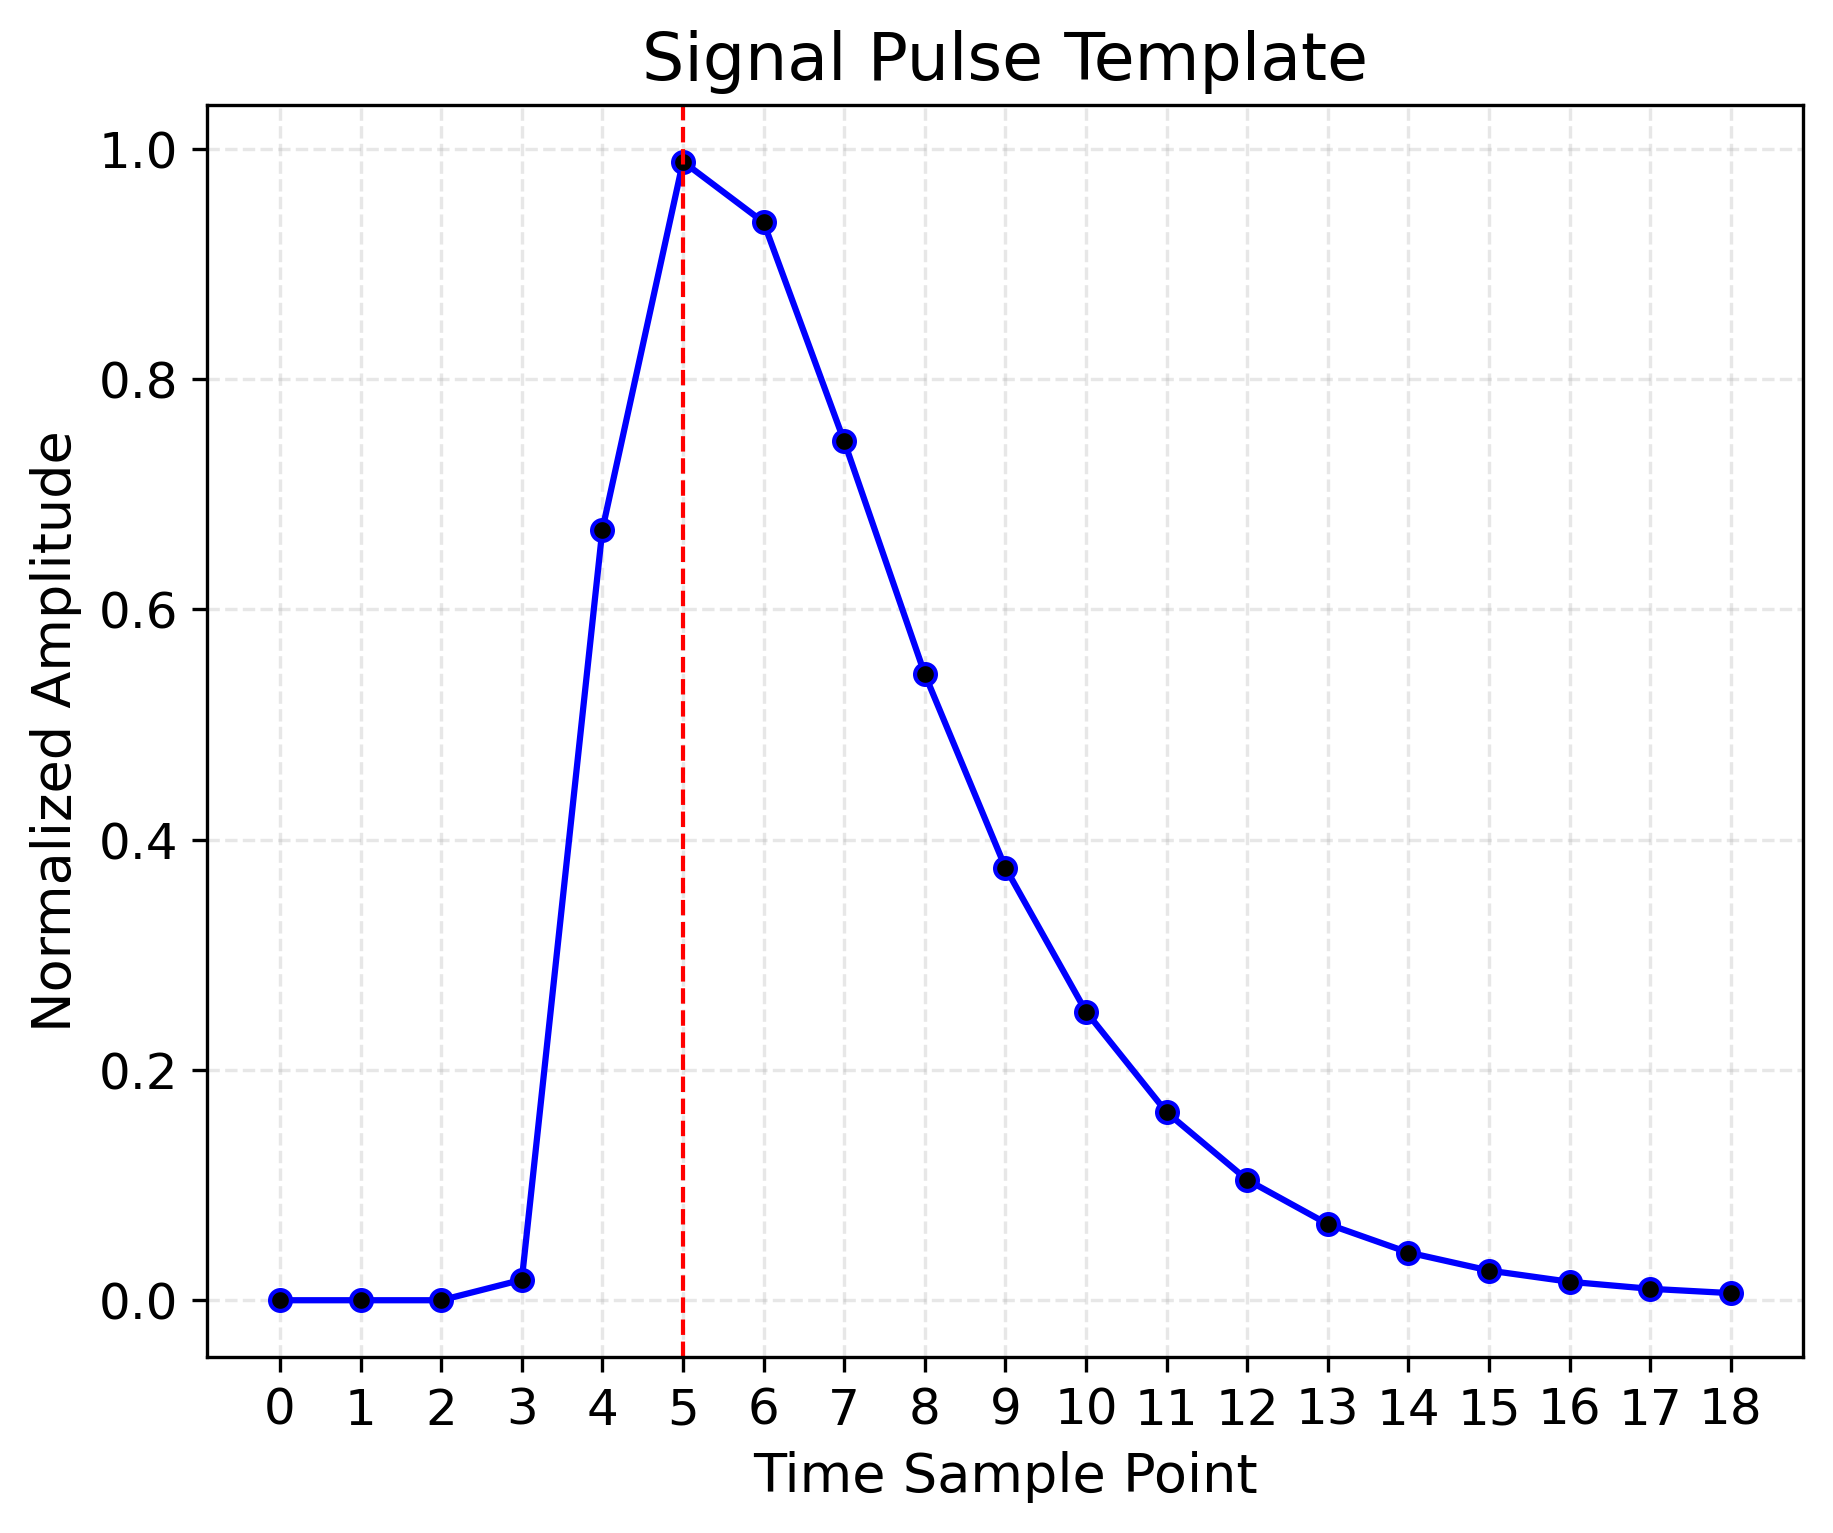

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(19)

# === PRL-style setup ===
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "figure.dpi": 300
})

# --- Square-ish figure ---
fig, ax = plt.subplots(figsize=(6, 5))

# --- Plot signal pulse ---
ax.plot(x, signal_shapes, marker='o', markersize=5, linestyle='-',
        color='blue', markerfacecolor='black')

# --- Vertical line at peak ---
ax.axvline(x=5, color='red', linestyle='--', linewidth=1)

# --- Axis labels and title ---
ax.set_xlabel("Time Sample Point", fontsize=13)
ax.set_ylabel("Normalized Amplitude", fontsize=13)
ax.set_title("Signal Pulse Template", fontsize=16)
ax.set_xticks(np.arange(0, 19, 1))

# --- Grid ---
ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8)

# --- Layout and save ---
fig.tight_layout(pad=0.2)
#plt.savefig("Paper_Plots/Signal_Pulse_Template.png", dpi=600, bbox_inches="tight")
plt.show()

In [4]:
with uproot.open('CMS_work/project/build/electron_Shilpidi_5GeV_10000box0.root') as f:
    tree = f["ntuple/pi0_tree"] # can access TTrees by name
    data_events = tree.arrays(library = "pd")


energy_branches = [k for k in tree.keys() if k.startswith('E_')]
data_events = tree.arrays(energy_branches, library="pd")

In [5]:
signal_amp = data_events.values
signal_energy = np.sum(signal_amp, axis = 1)
signal_shapes = signal_shapes.reshape(1, 1, -1)
signal_timeSamples = signal_amp[:, :, np.newaxis] * signal_shapes


In [6]:
signal_timeSamples.shape

(4000, 2601, 19)

In [7]:
uncorrelated_noiseAmp = np.random.normal(0, 1, signal_timeSamples.shape[0]*signal_timeSamples.shape[1]*19)
uncorrelated_noiseAmp = uncorrelated_noiseAmp.reshape(-1,19)
NSAMPLES = 19
NFREQ = 25
TAU = 30.0

mC_ = np.zeros(NSAMPLES)
for i in range(NSAMPLES):
    y = 1.0 - np.exp(-(NFREQ * i) / (np.sqrt(2.0) * TAU))
    mC_[i] = 1.0 - y * y

covariance_matrix = np.zeros((NSAMPLES, NSAMPLES))
for i in range(NSAMPLES):
    for j in range(NSAMPLES):
        m = abs(i - j)
        covariance_matrix[i, j] = mC_[m]

In [10]:
L = np.linalg.cholesky(covariance_matrix)          # covariance_matrix = L @ L.T

assert np.allclose(L @ L.T, covariance_matrix), \
    "Cholesky convention mismatch: expected lower factor with Sigma = L @ L.T"

correlated_noise = np.dot(uncorrelated_noiseAmp, L.T)

# Empirical check on a subsample -- catches the orientation error directly
# rather than inferring it later from an unexpected NOISE_SIGMA.
_emp = np.cov(correlated_noise[:20000], rowvar=False)
_max_dev = np.abs(_emp - covariance_matrix).max()
print(f"noise covariance check: max |empirical - target| = {_max_dev:.4f} ")
assert _max_dev < 0.15, "generated noise does not match the target covariance"

correlated_noise = correlated_noise.reshape(-1,2601,19)

noise_amp = 150
noise_timeSamples = noise_amp*correlated_noise
signalNoise_timeSamples = signal_timeSamples + noise_timeSamples

noise covariance check: max |empirical - target| = 0.0231 


In [11]:
X = signalNoise_timeSamples[:,:,0:10]
Y = signal_timeSamples[:,:,0:10]

X_flat = X.reshape(-1, 10)
Y_flat = Y.reshape(-1, 10)

X_max = np.max(np.abs(X_flat), axis=1, keepdims=True).astype(np.float32)
X_max = np.where(X_max == 0, 1.0, X_max)

# Save raw (unnormalised) values — normalisation happens post-split in Cell 12
X_norm = X_flat.astype(np.float32)
y_norm = Y_flat.astype(np.float32)

COV10 = covariance_matrix[:10, :10]
L10   = np.linalg.cholesky(COV10)               # COV10 = L10 @ L10.T
W10   = np.linalg.inv(L10)                       # whitening: w = W10 @ x
# Row-vector convention: X_w = X @ W10.T  =>  Cov(row) = noise_amp^2 * I
print(f"whitening operator ready | cond(L10) = {np.linalg.cond(L10):.2f}")

whitening operator ready | cond(L10) = 9.49


In [12]:
import uproot

chunk = 500
n_crystals = 2601

with uproot.recreate("LSTM_Data.root") as file:
    for i in range(0, 4000, chunk):
        start = i * n_crystals
        end = (i + chunk) * n_crystals
        d = {
            "X_noisy":    X_norm[start:end],
            "y_clean":    y_norm[start:end],
            "signal_amp": signal_amp.reshape(-1)[start:end].astype(np.float32),
            "X_max":      X_max.reshape(-1)[start:end],
            }
        if i == 0:
            file["Samples"] = d
        else:
            file["Samples"].extend(d)

print("Saved LSTM_Data.root")

Saved LSTM_Data.root


=== Check 1: File Keys ===
['Samples;1']
<class 'uproot.models.RNTuple.Model_ROOT_3a3a_RNTuple'>

=== Check 2: Branch Names and Total Entries ===
['X_max', 'X_noisy', 'signal_amp', 'y_clean']
Total entries: 10404000

=== Check 3: Shapes ===
X_noisy shape: (10404000, 10)
Y_clean shape: (10404000, 10)
signal_amp shape: (10404000,)
X_max shape: (10404000,)

=== Check 4: Value Ranges ===
X_noisy min/max: -829.8756 8207.65
Y_clean min/max: 0.0 7916.8076
signal_amp min/max: 0.0 8004.7744
X_max min/max: 15.723311 8207.65

=== Check 5: Signal vs Noise Crystal Counts ===
Signal crystals: 642881
Noise crystals: 9761119
Signal fraction: 6.18%

=== Check 6: Single Signal Crystal ===


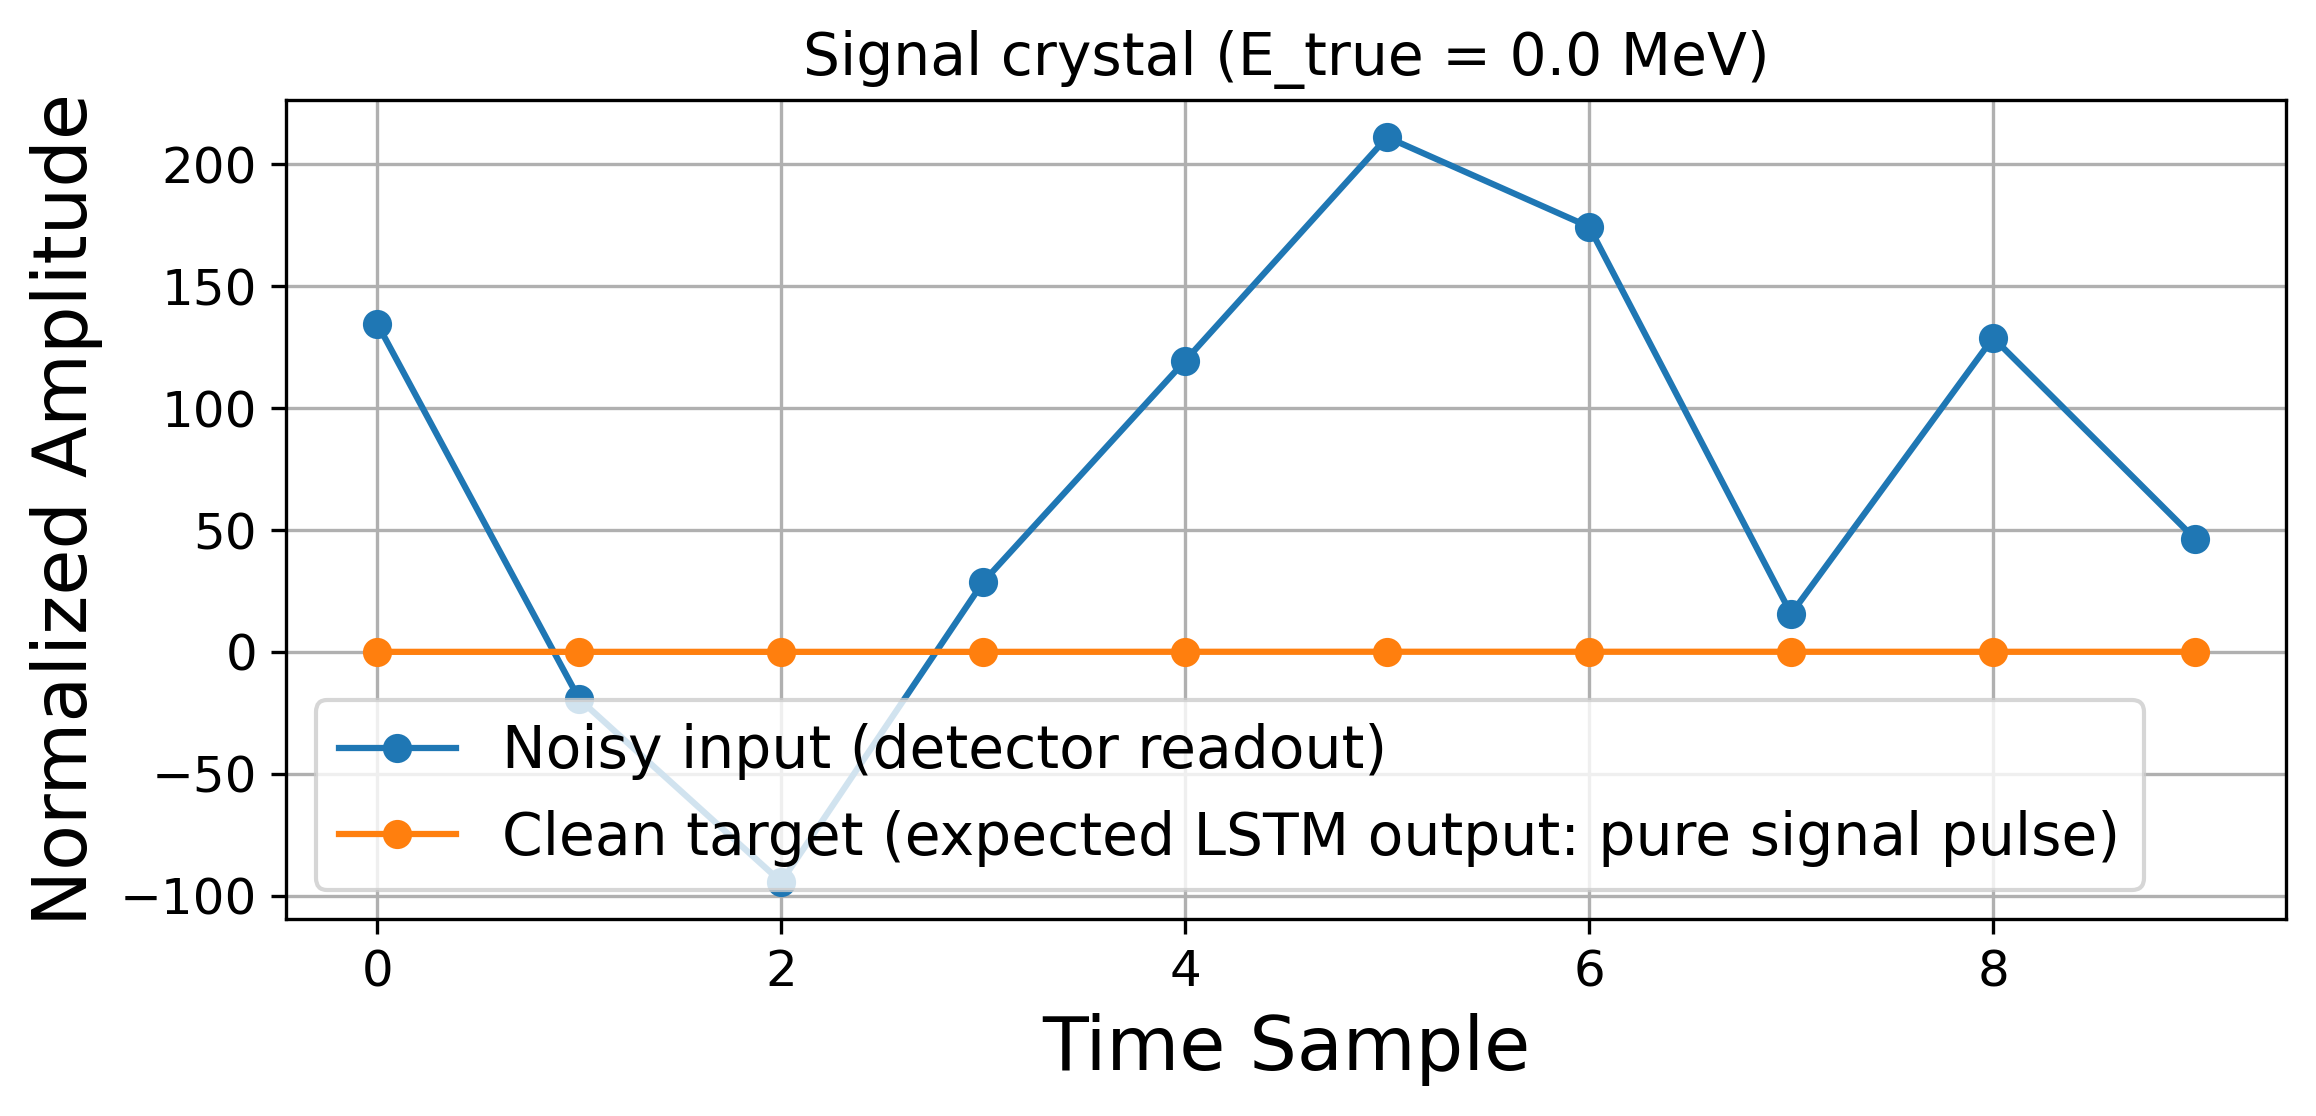


=== Check 7: Single Noise Crystal ===


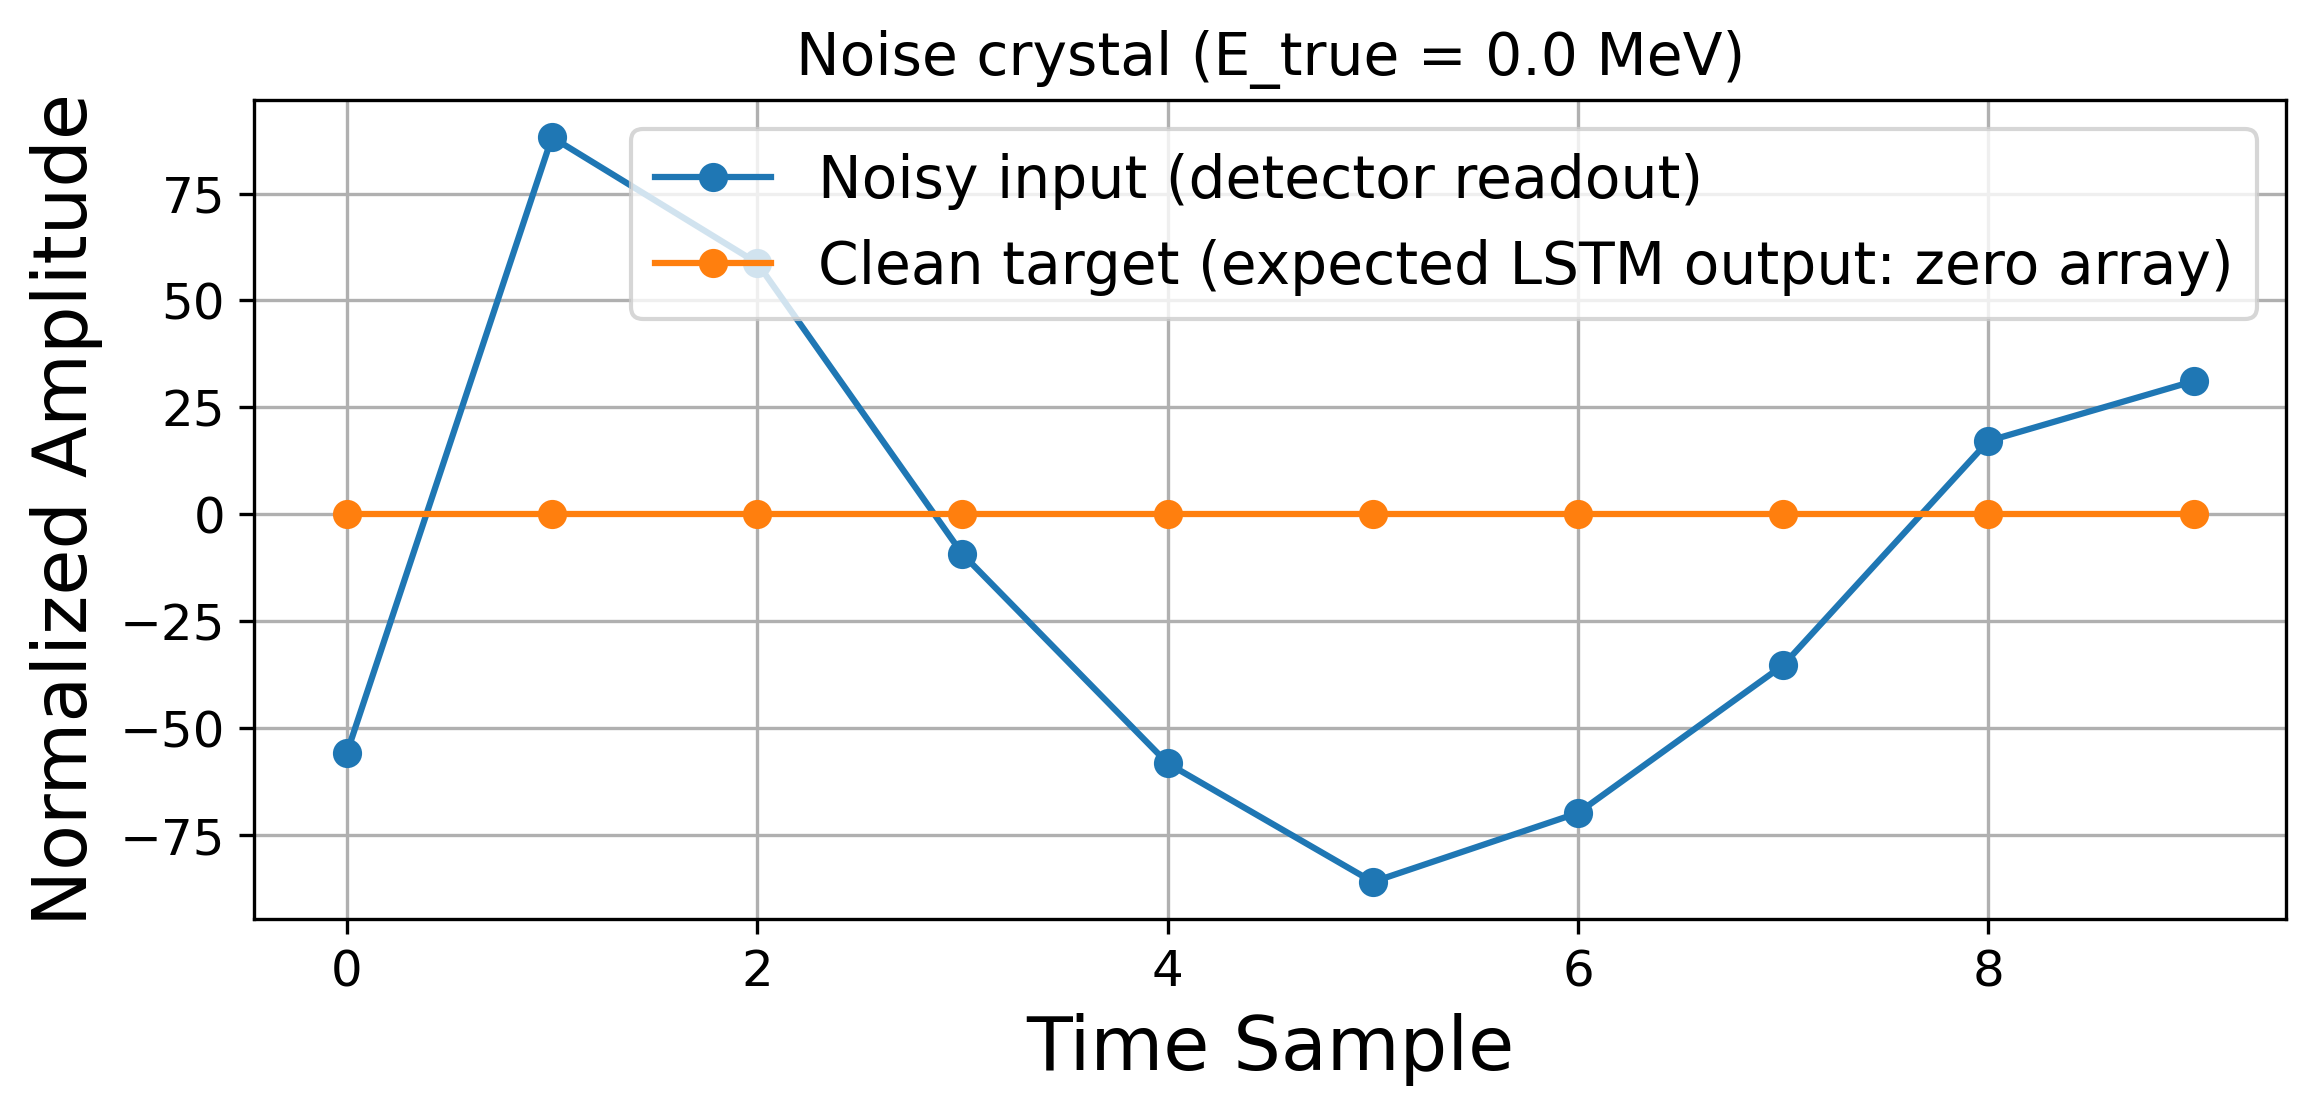

In [13]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

f = uproot.open("LSTM_Data.root")
print("=== Check 1: File Keys ===")
print(f.keys())
print(type(f["Samples"]))

print("\n=== Check 2: Branch Names and Total Entries ===")
tree = f["Samples"]
print(tree.keys())
print("Total entries:", tree.num_entries)

print("\n=== Check 3: Shapes ===")
arr = tree.arrays(library="ak")
X_noisy    = ak.to_numpy(arr["X_noisy"])
Y_clean    = ak.to_numpy(arr["y_clean"])
signal_amp = ak.to_numpy(arr["signal_amp"])
X_max      = ak.to_numpy(arr["X_max"])

print("X_noisy shape:", X_noisy.shape)
print("Y_clean shape:", Y_clean.shape)
print("signal_amp shape:", signal_amp.shape)
print("X_max shape:", X_max.shape)

print("\n=== Check 4: Value Ranges ===")
print("X_noisy min/max:", X_noisy.min(), X_noisy.max())
print("Y_clean min/max:", Y_clean.min(), Y_clean.max())
print("signal_amp min/max:", signal_amp.min(), signal_amp.max())
print("X_max min/max:", X_max.min(), X_max.max())

print("\n=== Check 5: Signal vs Noise Crystal Counts ===")
signal_mask = signal_amp > 0
print(f"Signal crystals: {signal_mask.sum()}")
print(f"Noise crystals: {(~signal_mask).sum()}")
print(f"Signal fraction: {signal_mask.mean()*100:.2f}%")

print("\n=== Check 6: Single Signal Crystal ===")
idx = np.where(signal_mask)[0][0]
plt.figure(figsize=(8, 4))
plt.plot(X_noisy[idx], marker='o', label=f'Noisy input (detector readout)')
plt.plot(Y_clean[idx], marker='o', label=f'Clean target (expected LSTM output: pure signal pulse)')
plt.xlabel("Time Sample")
plt.ylabel("Normalized Amplitude")
plt.title(f"Signal crystal (E_true = {signal_amp[idx]:.1f} MeV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== Check 7: Single Noise Crystal ===")
idx = np.where(~signal_mask)[0][0]
plt.figure(figsize=(8, 4))
plt.plot(X_noisy[idx], marker='o', label='Noisy input (detector readout)')
plt.plot(Y_clean[idx], marker='o', label='Clean target (expected LSTM output: zero array)')
plt.xlabel("Time Sample")
plt.ylabel("Normalized Amplitude")
plt.title(f"Noise crystal (E_true = {signal_amp[idx]:.1f} MeV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn as nn
import numpy as np
import uproot
import awkward as ak
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import os
import time

# Load data
f = uproot.open("LSTM_Data.root")
tree = f["Samples"]
arr = tree.arrays(library="ak")

X_noisy    = ak.to_numpy(arr["X_noisy"]).astype(np.float32)    # (10404000, 10)
Y_clean    = ak.to_numpy(arr["y_clean"]).astype(np.float32)    # (10404000, 10)
signal_amp = ak.to_numpy(arr["signal_amp"]).astype(np.float32) # (10404000,)
X_max      = ak.to_numpy(arr["X_max"]).astype(np.float32)      # (10404000,)

print("X_noisy shape:", X_noisy.shape)
print("Y_clean shape:", Y_clean.shape)
print("signal_amp shape:", signal_amp.shape)
print("X_max shape:", X_max.shape)

X_noisy shape: (10404000, 10)
Y_clean shape: (10404000, 10)
signal_amp shape: (10404000,)
X_max shape: (10404000,)


In [15]:
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(np.arange(len(X_noisy)), test_size=0.30, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.833, random_state=42)

print(f"Train samples:      {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples:       {len(test_idx)}")

GLOBAL_SCALE = float(np.percentile(signal_amp[train_idx][signal_amp[train_idx] > 0], 99))
print(f"GLOBAL_SCALE (99th pct of nonzero train energies): {GLOBAL_SCALE:.2f} MeV")

def normalize_split(X, Y, scale=GLOBAL_SCALE):
    X_norm = (X / scale).astype(np.float32)
    Y_norm = (Y / scale).astype(np.float32)
    return X_norm, Y_norm

X_train_norm, Y_train_norm = normalize_split(X_noisy[train_idx], Y_clean[train_idx])
X_val_norm,   Y_val_norm   = normalize_split(X_noisy[val_idx],   Y_clean[val_idx])
X_test_norm,  Y_test_norm  = normalize_split(X_noisy[test_idx],  Y_clean[test_idx])

def whiten(Xn):
    return (Xn @ W10.T).astype(np.float32)

X_train_w = whiten(X_train_norm)
X_val_w   = whiten(X_val_norm)
X_test_w  = whiten(X_test_norm)
print(f"input std, raw vs whitened (train): {X_train_norm.std():.4f} -> {X_train_w.std():.4f}")

# Convert to tensors (including signal_amp for binary mask loss weighting)
X_train   = torch.tensor(X_train_w).unsqueeze(-1)
Y_train   = torch.tensor(Y_train_norm).unsqueeze(-1)
amp_train = torch.tensor(signal_amp[train_idx], dtype=torch.float32)

X_val   = torch.tensor(X_val_w).unsqueeze(-1)
Y_val   = torch.tensor(Y_val_norm).unsqueeze(-1)
amp_val = torch.tensor(signal_amp[val_idx], dtype=torch.float32)

X_test   = torch.tensor(X_test_w).unsqueeze(-1)
Y_test   = torch.tensor(Y_test_norm).unsqueeze(-1)
amp_test = torch.tensor(signal_amp[test_idx], dtype=torch.float32)

# Full-dataset DataLoaders with amplitude tensor
batch_size = 512

train_loader = DataLoader(TensorDataset(X_train, Y_train, amp_train), batch_size=batch_size, shuffle=True,  drop_last=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val,   Y_val,   amp_val),   batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test,  Y_test,  amp_test),  batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train samples:      7282800
Validation samples: 521240
Test samples:       2599960
GLOBAL_SCALE (99th pct of nonzero train energies): 1723.15 MeV
input std, raw vs whitened (train): 0.0924 -> 0.0898
Train batches: 14224
Val batches:   1018
Test batches:  5078


=== Check 1: target now carries energy information? ===
Correlation(true energy, normalized target peak): r = 1.0000  (want close to 1.0)
Y_norm peak on signal crystals -> min=0.0000, max=4.5944, std=0.2118
  (old bug: this was pinned at exactly 1.0000 for every signal crystal, std ~ 0)

=== Check 2: input scale consistent across crystal types? ===
|X_norm| max — noise crystals:  mean=0.1442, 99th pct=0.2798
|X_norm| max — signal crystals: mean=0.1698, 99th pct=0.9978
  (old bug: noise ~150x larger than signal; want same order of magnitude now)


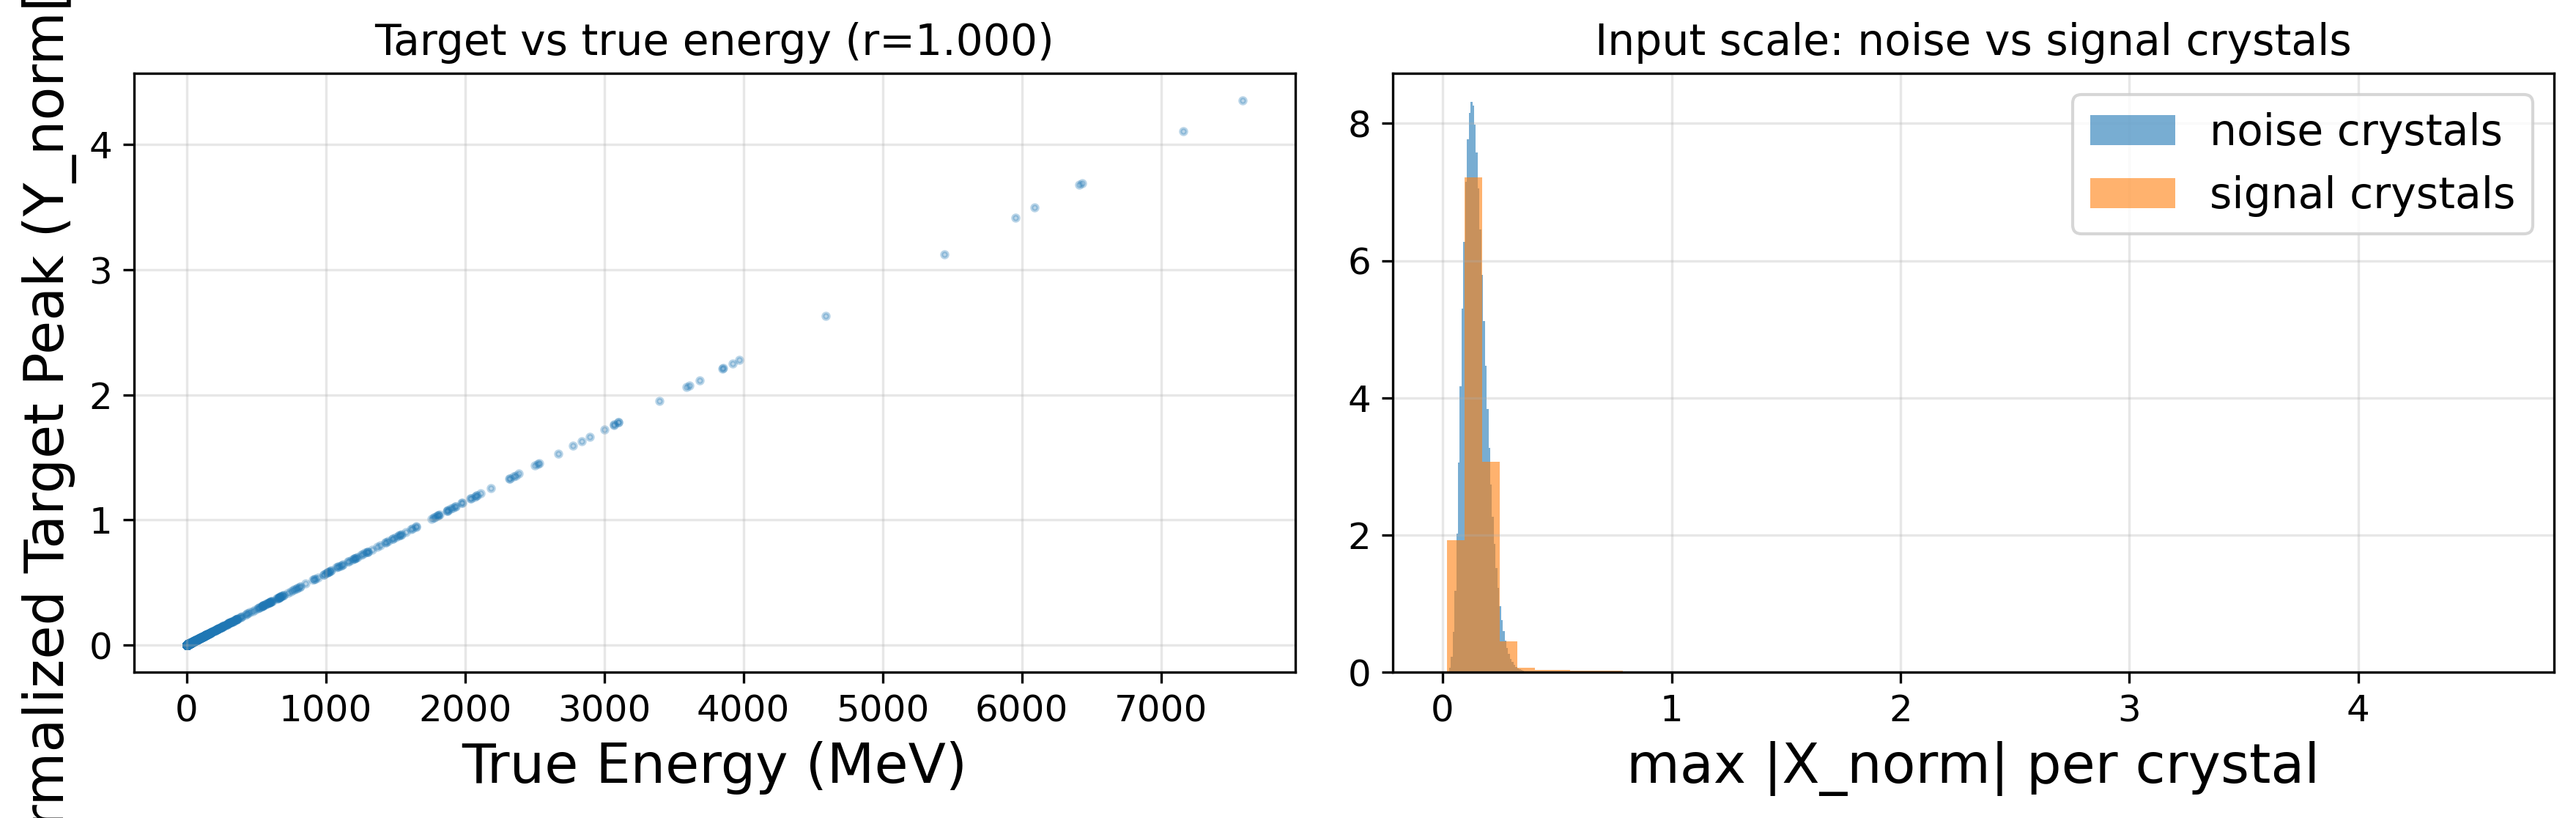

In [16]:
# ── Diagnose the normalization fix BEFORE running the full model ──────────
# Cheap, GPU-free checks on data already prepared above.

sig_mask_train = signal_amp[train_idx] > 0
amp_sig_train  = signal_amp[train_idx][sig_mask_train]
Y_peak_train   = Y_train_norm[:, 5]                 # normalized target peak (t=5)
Y_peak_sig     = Y_peak_train[sig_mask_train]

# Check 1: target peak should now vary WITH true energy, not sit pinned at 1.0
r = np.corrcoef(amp_sig_train, Y_peak_sig)[0, 1]
print("=== Check 1: target now carries energy information? ===")
print(f"Correlation(true energy, normalized target peak): r = {r:.4f}  (want close to 1.0)")
print(f"Y_norm peak on signal crystals -> min={Y_peak_sig.min():.4f}, "
      f"max={Y_peak_sig.max():.4f}, std={Y_peak_sig.std():.4f}")
print("  (old bug: this was pinned at exactly 1.0000 for every signal crystal, std ~ 0)")

# Check 2: input scale should now be consistent between noise and signal crystals
X_abs_max_train = np.max(np.abs(X_train_norm), axis=1)
noise_scale  = X_abs_max_train[~sig_mask_train]
signal_scale = X_abs_max_train[sig_mask_train]
print("\n=== Check 2: input scale consistent across crystal types? ===")
print(f"|X_norm| max — noise crystals:  mean={noise_scale.mean():.4f}, 99th pct={np.percentile(noise_scale,99):.4f}")
print(f"|X_norm| max — signal crystals: mean={signal_scale.mean():.4f}, 99th pct={np.percentile(signal_scale,99):.4f}")
print("  (old bug: noise ~150x larger than signal; want same order of magnitude now)")

# Check 3: visual sanity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample = np.random.choice(len(amp_sig_train), size=min(5000, len(amp_sig_train)), replace=False)
axes[0].scatter(amp_sig_train[sample], Y_peak_sig[sample], s=4, alpha=0.3)
axes[0].set_xlabel("True Energy (MeV)")
axes[0].set_ylabel("Normalized Target Peak (Y_norm[t=5])")
axes[0].set_title(f"Target vs true energy (r={r:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].hist(noise_scale, bins=60, alpha=0.6, label="noise crystals", density=True)
axes[1].hist(signal_scale, bins=60, alpha=0.6, label="signal crystals", density=True)
axes[1].set_xlabel("max |X_norm| per crystal")
axes[1].set_title("Input scale: noise vs signal crystals")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
from torch import nn
import torch

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers=3, dropout=0.25):
        super(VAE, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # ── Encoder (bidirectional) ───────────────────────────────────────────
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Layer norm on encoder context for stable mu/log_var
        self.context_norm = nn.LayerNorm(hidden_dim * 2)

        # ── VAE Bottleneck ────────────────────────────────────────────────────
        # +1 input dim: matched-filter z-score feature (see forward()) -- gives
        # the encoder direct access to the optimal shape-match statistic
        # instead of relying on it to implicitly rediscover matched filtering
        # from the raw waveform alone.
        self.fc_mu      = nn.Linear(hidden_dim * 2 + 1, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim * 2 + 1, latent_dim)

        # Two-stage expansion latent → decoder initial states
        self.fc_h0 = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * num_layers)
        )
        self.fc_c0 = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * num_layers)
        )

        # ── Decoder (time steps + z at each step) ────────────────────────────
        self.decoder = nn.LSTM(
            input_size=1 + latent_dim,   # time position + latent code
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # ── Physics-aware output head ─────────────────────────────────────────
        self.amp_head   = nn.Linear(hidden_dim, 1)   # peak amplitude scalar
        self.shape_head = nn.Linear(hidden_dim, 1)   # per-timestep shape correction

        # Signal template buffer — set via set_signal_template() before training
        self.register_buffer('signal_template', torch.zeros(1, 10, 1))

    def set_signal_template(self, template):
        """Set the physics signal template. Call before wrapping in DataParallel."""
        self.signal_template.copy_(template)

    def reparameterize(self, mu, log_var):
        if not self.training:
            return mu
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, mf_feat):
        batch_size, seq_len, _ = x.shape

        # 1. Encode
        enc_out, (h_n, _) = self.encoder(x)
        context = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, hidden_dim*2)
        context = self.context_norm(context)
        # Signed-log squash: mf_feat's tail reaches ~90 (highest-energy crystals)
        # while context is LayerNorm'd to roughly unit scale -- squash before
        # concatenating so the raw magnitude can't dominate fc_mu/fc_log_var's
        # input. Monotonic and near-identity for small values, so no
        # information is discarded near the noise floor where it matters most.
        mf_feat_scaled = torch.sign(mf_feat) * torch.log1p(torch.abs(mf_feat))
        context = torch.cat([context, mf_feat_scaled.view(batch_size, 1)], dim=1)  # inject matched-filter z-score

        # 2. VAE Bottleneck
        mu      = self.fc_mu(context)
        log_var = self.fc_log_var(context)
        z       = self.reparameterize(mu, log_var)       # (batch, latent_dim)

        # 3. Initialize decoder hidden/cell states from z
        h0 = self.fc_h0(z).view(-1, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()
        c0 = self.fc_c0(z).view(-1, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        # 4. Decoder input: time steps concatenated with z at every step
        time_steps = torch.linspace(0, 1, steps=seq_len, device=x.device)
        time_input = time_steps.view(1, seq_len, 1).repeat(batch_size, 1, 1)
        z_expanded = z.unsqueeze(1).repeat(1, seq_len, 1)
        dec_input  = torch.cat([time_input, z_expanded], dim=-1)  # (batch, 10, 1+latent_dim)

        # 5. Decode
        dec_out, _ = self.decoder(dec_input, (h0, c0))
        dec_out    = self.dropout(dec_out)

        # 6. Physics-aware output: out = E * (S(t) + δS(t))
        amplitude     = torch.nn.functional.softplus(self.amp_head(dec_out[:, 5:6, :]))  # (batch, 1, 1) -- softplus not relu: avoids dead-unit collapse (see smoke-test cells)
        shape_correct = self.shape_head(dec_out)                        # (batch, 10, 1)
        out           = amplitude * (self.signal_template + shape_correct)

        return out, mu, log_var

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"GPUs available: {torch.cuda.device_count()}")

Device: cpu
GPUs available: 0


In [20]:
# Physics-informed signal template (normalized to peak 1.0 at t=5)
signal_template = torch.tensor(signal_shapes_10, dtype=torch.float32).to(device)
signal_template = (signal_template / signal_template[5]).view(1, 10, 1)

FREE_BITS    = 0.05
SIGNAL_BOOST = 50.0

# amp==0 crystals are true noise by definition 
NOISE_SIGMA = float(np.std(X_noisy[train_idx][signal_amp[train_idx] == 0]))
SNR_THRESHOLD = 3.0   # crystals below this many sigma above noise floor don't get boosted
SNR_SOFTNESS  = 1.0   
print(f"Empirical noise sigma: {NOISE_SIGMA:.2f}  |  SNR boost threshold: {SNR_THRESHOLD} sigma")

def vae_loss(pred, target, mu, log_var, amp_batch, beta=0.0005, free_bits=FREE_BITS,
             signal_boost=SIGNAL_BOOST, noise_sigma=NOISE_SIGMA,
             snr_threshold=SNR_THRESHOLD, snr_softness=SNR_SOFTNESS):
    
    snr    = amp_batch / noise_sigma
    ramp   = torch.sigmoid((snr - snr_threshold) / snr_softness)   # ~0 near/under noise floor, ->1 above it
    weight = (1.0 + (signal_boost - 1.0) * ramp).unsqueeze(-1).unsqueeze(-1)

    # ── Weighted Huber reconstruction loss ───────────────────────────────────
    raw_recon  = torch.nn.functional.huber_loss(pred, target, delta=1.0, reduction='none')
    recon_loss = torch.mean(weight * raw_recon)

    # ── Peak sample loss (sample index 5) ────────────────────────────────────
    raw_peak  = torch.nn.functional.huber_loss(pred[:, 5, :], target[:, 5, :], delta=1.0, reduction='none')
    peak_loss = torch.mean(weight.squeeze(-1) * raw_peak)

    # ── KL divergence with free bits ─────────────────────────────────────────
    kl_per_dim = -0.5 * (1 + log_var - mu**2 - torch.exp(log_var))
    kl_loss    = torch.mean(torch.clamp(kl_per_dim, min=free_bits).sum(dim=1))

    # ── Total loss (3-term: recon + peak + KL) ───────────────────────────────
    total = recon_loss + 0.5 * peak_loss + beta * kl_loss

    return total, recon_loss, peak_loss, kl_loss

Empirical noise sigma: 149.97  |  SNR boost threshold: 3.0 sigma


NOISE_SIGMA = 149.970
Current SNR_THRESHOLD=3.0, SNR_SOFTNESS=1.0, SIGNAL_BOOST=50.0

E=  17.1 MeV -> SNR=0.114 -> current weight=3.59x
E=  29.9 MeV -> SNR=0.199 -> current weight=3.81x
E=  50.0 MeV -> SNR=0.333 -> current weight=4.18x
E= 100.0 MeV -> SNR=0.667 -> current weight=5.33x
E= 300.0 MeV -> SNR=2.000 -> current weight=14.18x

=== Weight distribution across real signal crystals (train split) ===
Fraction of signal crystals with SNR < 1:                  94.9%
Fraction of signal crystals with SNR < 3.0 (below full threshold): 97.2%
Median weight for SNR<1 crystals:  3.36x
Median weight for SNR<3.0 crystals:  3.36x


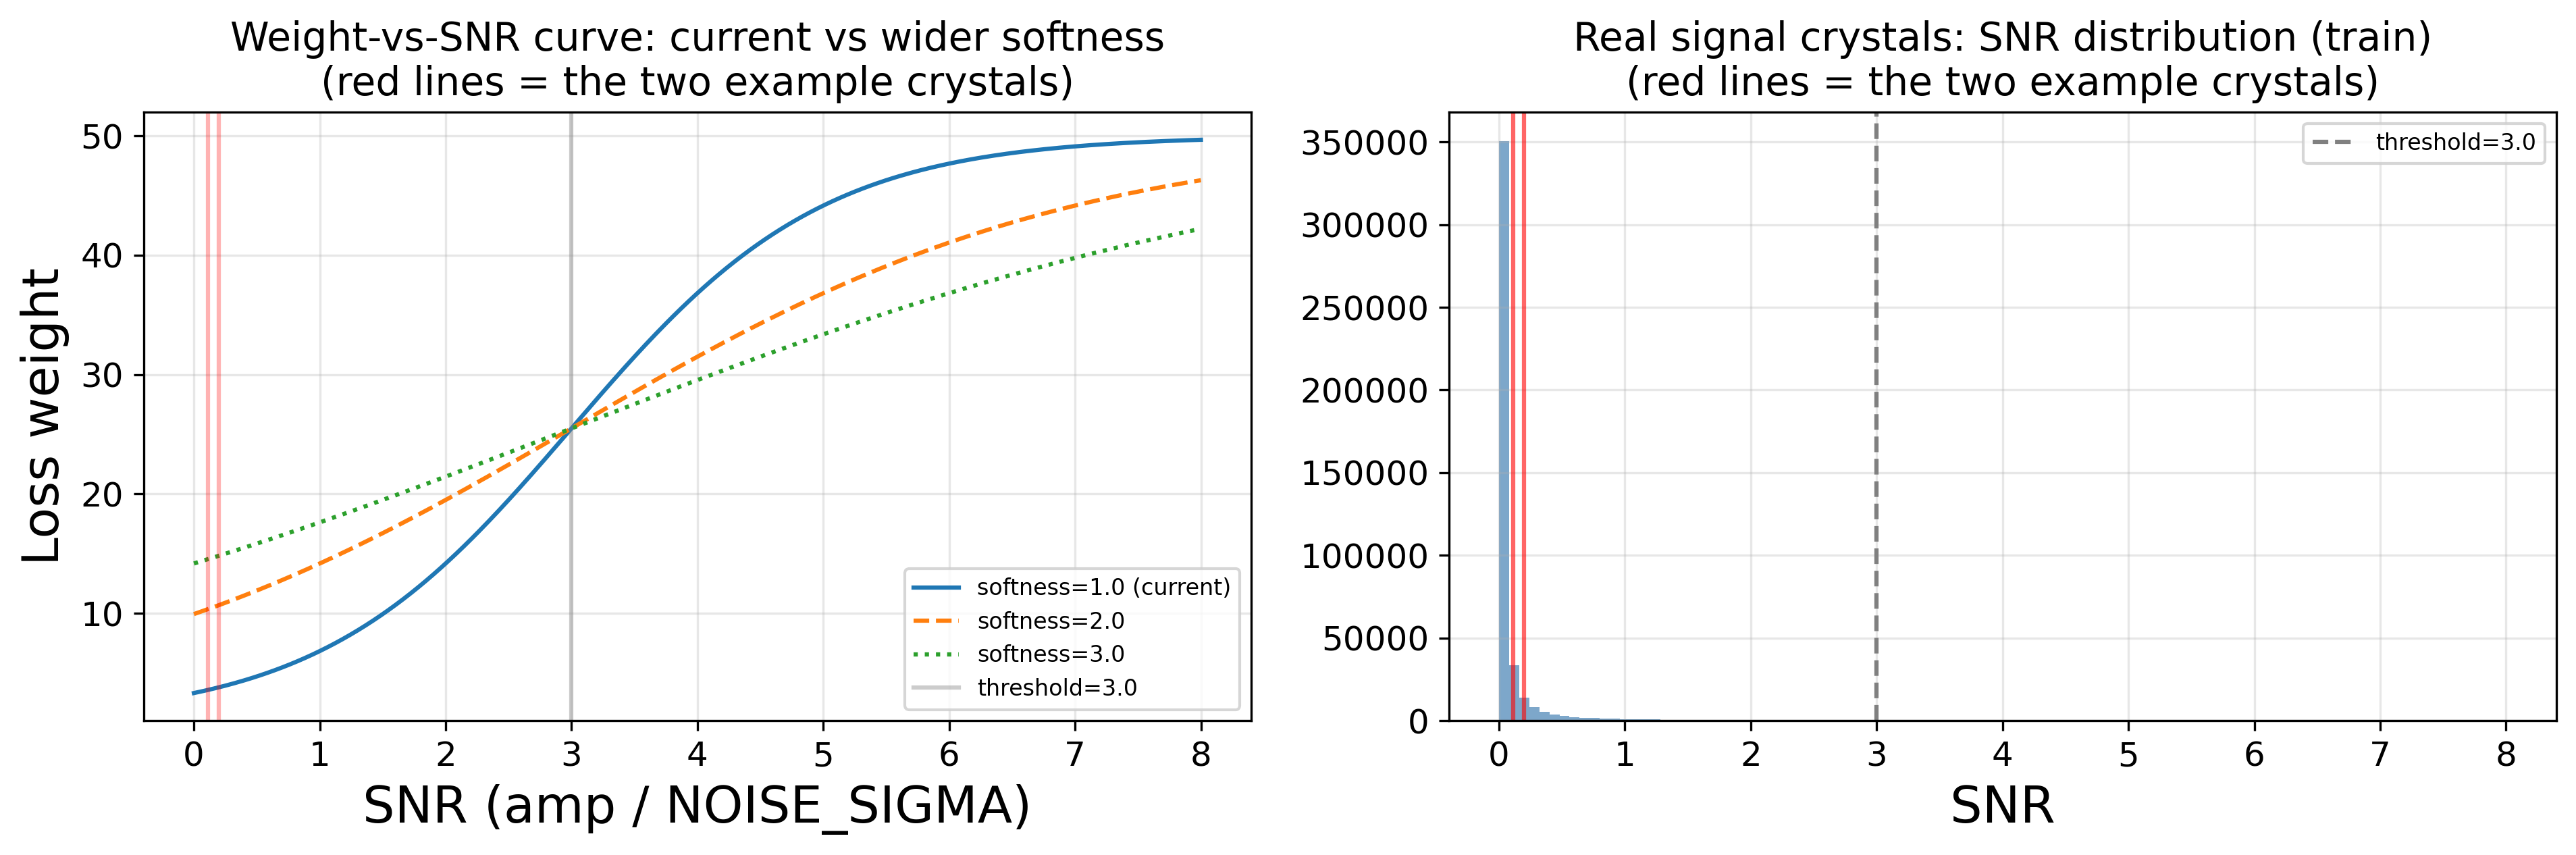

In [21]:
# ── Data-only diagnostic: how much loss-weight do low-SNR signal crystals actually get? ──
# Before touching SNR_THRESHOLD/SNR_SOFTNESS, quantify the CURRENT weighting
# curve using the exact formula from vae_loss(), and see precisely where the
# problem crystals (SNR ~0.1-0.2, e.g. the 17.1/29.9 MeV examples from the
# reconstruction plot) fall on it. No model needed -- pure function of
# signal_amp, NOISE_SIGMA, SNR_THRESHOLD, SIGNAL_BOOST, SNR_SOFTNESS, all
# already defined in the loss-function cell above.

def weight_curve(snr, threshold=SNR_THRESHOLD, softness=SNR_SOFTNESS, boost=SIGNAL_BOOST):
    ramp = 1.0 / (1.0 + np.exp(-(snr - threshold) / softness))
    return 1.0 + (boost - 1.0) * ramp

amp_train_np     = signal_amp[train_idx]
is_signal_train  = amp_train_np > 0
snr_train        = amp_train_np[is_signal_train] / NOISE_SIGMA
weight_train     = weight_curve(snr_train)

print(f"NOISE_SIGMA = {NOISE_SIGMA:.3f}")
print(f"Current SNR_THRESHOLD={SNR_THRESHOLD}, SNR_SOFTNESS={SNR_SOFTNESS}, SIGNAL_BOOST={SIGNAL_BOOST}")
print()

for E_example in [17.1, 29.9, 50, 100, 300]:
    snr_ex = E_example / NOISE_SIGMA
    w_ex = weight_curve(np.array([snr_ex]))[0]
    print(f"E={E_example:6.1f} MeV -> SNR={snr_ex:.3f} -> current weight={w_ex:.2f}x")

print(f"\n=== Weight distribution across real signal crystals (train split) ===")
print(f"Fraction of signal crystals with SNR < 1:                  {(snr_train < 1).mean()*100:.1f}%")
print(f"Fraction of signal crystals with SNR < {SNR_THRESHOLD} (below full threshold): {(snr_train < SNR_THRESHOLD).mean()*100:.1f}%")
print(f"Median weight for SNR<1 crystals:  {np.median(weight_train[snr_train < 1]):.2f}x")
print(f"Median weight for SNR<{SNR_THRESHOLD} crystals:  {np.median(weight_train[snr_train < SNR_THRESHOLD]):.2f}x")

# ── Compare current ramp vs candidate wider-softness ramps ───────────────────
snr_range = np.linspace(0, 8, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for softness, style in [(SNR_SOFTNESS, '-'), (2.0, '--'), (3.0, ':')]:
    w = weight_curve(snr_range, softness=softness)
    label = f'softness={softness}' + (' (current)' if softness == SNR_SOFTNESS else '')
    axes[0].plot(snr_range, w, style, label=label)
axes[0].axvline(SNR_THRESHOLD, color='gray', linestyle='-', alpha=0.4, label=f'threshold={SNR_THRESHOLD}')
for E_example in [17.1, 29.9]:
    axes[0].axvline(E_example / NOISE_SIGMA, color='red', alpha=0.3)
axes[0].set_xlabel("SNR (amp / NOISE_SIGMA)")
axes[0].set_ylabel("Loss weight")
axes[0].set_title("Weight-vs-SNR curve: current vs wider softness\n(red lines = the two example crystals)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(snr_train, bins=100, range=(0, 8), color='steelblue', alpha=0.7)
axes[1].axvline(SNR_THRESHOLD, color='gray', linestyle='--', label=f'threshold={SNR_THRESHOLD}')
for E_example in [17.1, 29.9]:
    axes[1].axvline(E_example / NOISE_SIGMA, color='red', alpha=0.6)
axes[1].set_xlabel("SNR")
axes[1].set_title("Real signal crystals: SNR distribution (train)\n(red lines = the two example crystals)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:

template_np_feat = signal_template.view(-1).cpu()                     # S(t), original basis
W10_t            = torch.tensor(W10, dtype=torch.float32)
template_w       = template_np_feat @ W10_t.T                          # S_w = W10 @ S
sigma_white      = float(noise_amp)                                    # per-sample sigma after whitening

# Verify the gain in-place. For a deposit of amplitude A the separation (in
# units of the statistic's own noise sigma) is:
#   plain MF     : A * ||S||^2 / sqrt(S^T C S)        <- noise std is NOT 1 here
#   whitened MF  : A * ||S_w|| / sigma_white           <- noise std IS 1 here
_C10  = (float(noise_amp) ** 2) * COV10                       # true covariance, MeV^2
_S    = template_np_feat.numpy().astype(np.float64)
_sep_plain = (_S @ _S) / np.sqrt(_S @ _C10 @ _S)
_sep_white = float(template_w.norm()) / sigma_white
print(f"||S|| = {template_np_feat.norm():.4f} (raw)  ->  ||S_w|| = {template_w.norm():.4f} (whitened)")
print(f"separation per MeV: plain {_sep_plain:.6f}  ->  whitened {_sep_white:.6f}")
print(f"separation gain = {_sep_white/_sep_plain:.3f}x  ({20*np.log10(_sep_white/_sep_plain):.2f} dB)  [expect ~1.314x, +2.37 dB]")

def compute_mf_z(idx):
    X_raw = torch.tensor(X_noisy[idx], dtype=torch.float32)              # (N, 10) raw, original basis
    X_w   = X_raw @ W10_t.T                                              # whiten
    mf_num = (X_w * template_w).sum(dim=1)
    return (mf_num / (sigma_white * template_w.norm())).float()          # ~N(0,1) under noise-only

mf_z_train = compute_mf_z(train_idx)
mf_z_val   = compute_mf_z(val_idx)
mf_z_test  = compute_mf_z(test_idx)

print(f"mf_z stats — train: mean={mf_z_train.mean():.3f}, std={mf_z_train.std():.3f}")
print(f"mf_z stats — val:   mean={mf_z_val.mean():.3f}, std={mf_z_val.std():.3f}")

# Rebuild loaders (defined in Cell 12) with the extra per-crystal feature included
train_loader = DataLoader(TensorDataset(X_train, Y_train, amp_train, mf_z_train), batch_size=batch_size, shuffle=True,  drop_last=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val,   Y_val,   amp_val,   mf_z_val),   batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test,  Y_test,  amp_test,  mf_z_test),  batch_size=batch_size, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)

print("Rebuilt train/val/test loaders with mf_z feature included.")


||S|| = 1.8359 (raw)  ->  ||S_w|| = 1.2960 (whitened)
separation per MeV: plain 0.006575  ->  whitened 0.008640
separation gain = 1.314x  (2.37 dB)  [expect ~1.314x, +2.37 dB]
mf_z stats — train: mean=0.033, std=1.277
mf_z stats — val:   mean=0.031, std=1.272
Rebuilt train/val/test loaders with mf_z feature included.


=== mf_z separation on TRAIN split ===
Noise  crystals — z mean/std: -0.000 / 1.000
Signal crystals — z mean/std: 0.541 / 3.306

Correlation(true energy, mf_z) on signal crystals: r = 0.9531  (want clearly > 0 -- confirms a learnable mapping exists)

=== Scale check: mf_z vs a LayerNorm'd context vector (roughly unit scale) ===
mf_z percentiles — 1%: -2.32, 50%: 0.01, 99%: 2.43, 99.9%: 9.25, max: 68.77
Fraction of crystals with |mf_z| > 5: 0.15%  (these inject a much larger-magnitude value into fc_mu/fc_log_var's input than the ~unit-scale LayerNorm'd context)


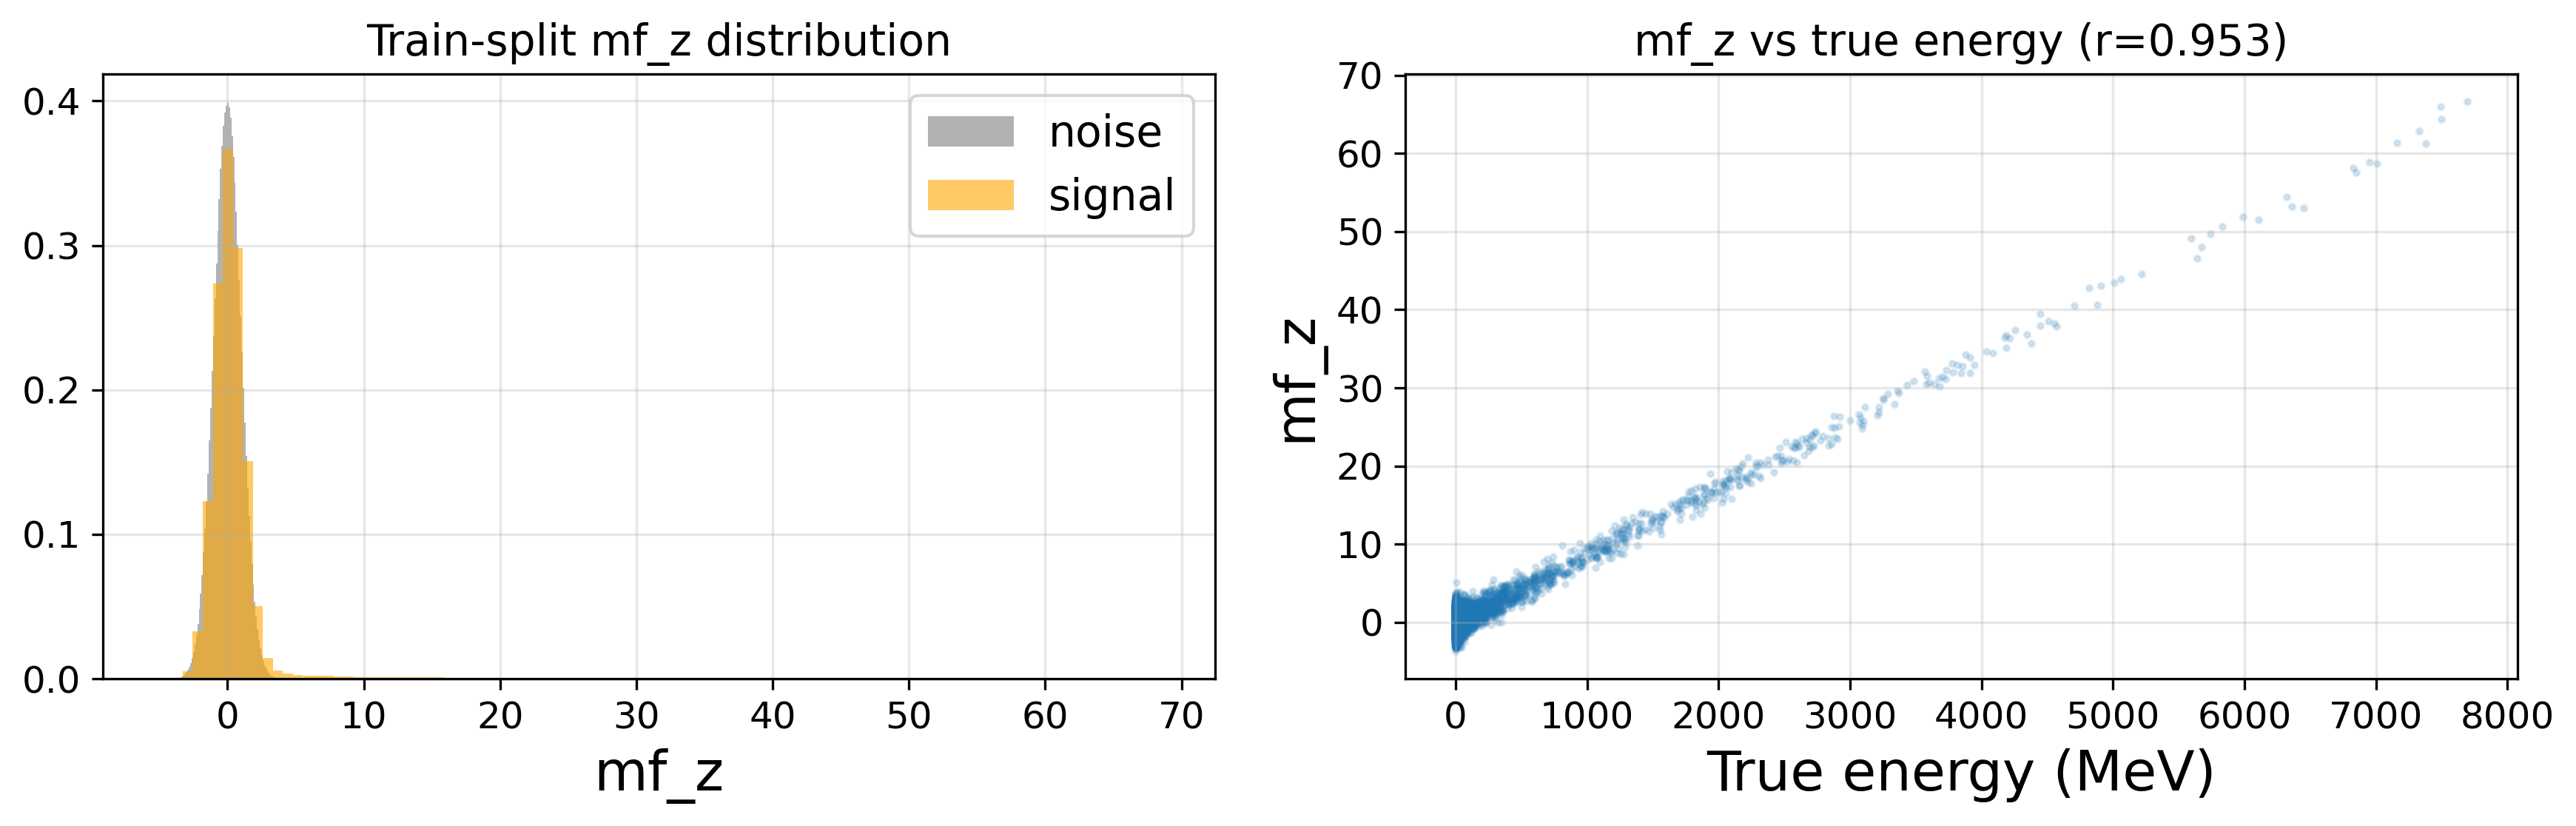

In [23]:
# ── Data-only check: does the injected mf_z feature actually carry what we want? ──
# No model needed -- inspect the feature itself before committing to a
# training run. Three questions: (1) does mf_z separate true signal from true
# noise on the TRAIN split specifically (the data the model will actually
# learn from), (2) does it correlate with true energy for signal crystals (a
# strong mapping is learnable), (3) is its SCALE compatible with being
# concatenated onto a LayerNorm'd context vector? LayerNorm output is roughly
# unit-scale; if mf_z has a much heavier tail, it could dominate
# fc_mu/fc_log_var's input for high-energy crystals and destabilize early
# training before the network learns to downweight that one dimension.

is_signal_train = signal_amp[train_idx] > 0
amp_train_np    = signal_amp[train_idx]
mf_z_train_np   = mf_z_train.numpy()

print("=== mf_z separation on TRAIN split ===")
print(f"Noise  crystals — z mean/std: {mf_z_train_np[~is_signal_train].mean():.3f} / {mf_z_train_np[~is_signal_train].std():.3f}")
print(f"Signal crystals — z mean/std: {mf_z_train_np[is_signal_train].mean():.3f} / {mf_z_train_np[is_signal_train].std():.3f}")

r = np.corrcoef(amp_train_np[is_signal_train], mf_z_train_np[is_signal_train])[0, 1]
print(f"\nCorrelation(true energy, mf_z) on signal crystals: r = {r:.4f}  (want clearly > 0 -- confirms a learnable mapping exists)")

print(f"\n=== Scale check: mf_z vs a LayerNorm'd context vector (roughly unit scale) ===")
print(f"mf_z percentiles — 1%: {np.percentile(mf_z_train_np, 1):.2f}, 50%: {np.percentile(mf_z_train_np, 50):.2f}, "
      f"99%: {np.percentile(mf_z_train_np, 99):.2f}, 99.9%: {np.percentile(mf_z_train_np, 99.9):.2f}, max: {mf_z_train_np.max():.2f}")
frac_large = (np.abs(mf_z_train_np) > 5).mean()
print(f"Fraction of crystals with |mf_z| > 5: {frac_large*100:.2f}%  "
      f"(these inject a much larger-magnitude value into fc_mu/fc_log_var's input than the ~unit-scale LayerNorm'd context)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mf_z_train_np[~is_signal_train], bins=100, alpha=0.6, label='noise', color='gray', density=True)
axes[0].hist(mf_z_train_np[is_signal_train],  bins=100, alpha=0.6, label='signal', color='orange', density=True)
axes[0].set_xlabel("mf_z"); axes[0].legend(); axes[0].set_title("Train-split mf_z distribution")
axes[0].grid(True, alpha=0.3)

sample_n = min(20000, is_signal_train.sum())
sig_idx_sample = np.where(is_signal_train)[0]
sig_idx_sample = np.random.choice(sig_idx_sample, size=sample_n, replace=False)
axes[1].scatter(amp_train_np[sig_idx_sample], mf_z_train_np[sig_idx_sample], s=3, alpha=0.15)
axes[1].set_xlabel("True energy (MeV)"); axes[1].set_ylabel("mf_z")
axes[1].set_title(f"mf_z vs true energy (r={r:.3f})")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


=== Hard floors for amplitude estimation on this dataset ===
||W S||^2 = 1.6796
Cramer-Rao bound (any UNBIASED estimator):  115.74 MeV
Raw peak sample as an amplitude estimate:   150.00 MeV
  -> optimal linear filtering buys only 1.30x. Anything beyond
     that must come from BIAS (shrinkage toward the mostly-empty prior).

sufficient-statistic self-check on true-noise val crystals:
  mean = -0.123 MeV (expect ~0), std = 115.76 MeV (expect ~116)

prior: P(A==0) = 0.93823 | 449,861 nonzero train crystals -> 5376 atoms at 0.67 MeV resolution (<< the 116 MeV kernel width, so binning is not the limit)

estimator                             r  resid std  mean res  noise mean  noise 95%
-----------------------------------------------------------------------------------
MMSE  E[A|t]  (Bayes floor)      0.9918      46.88    -13.91      0.8832     1.9508
MAP                              0.9871      58.65    -17.15      0.0012     0.0000
whitened MF, clipped >=0         0.9790      74.83     39

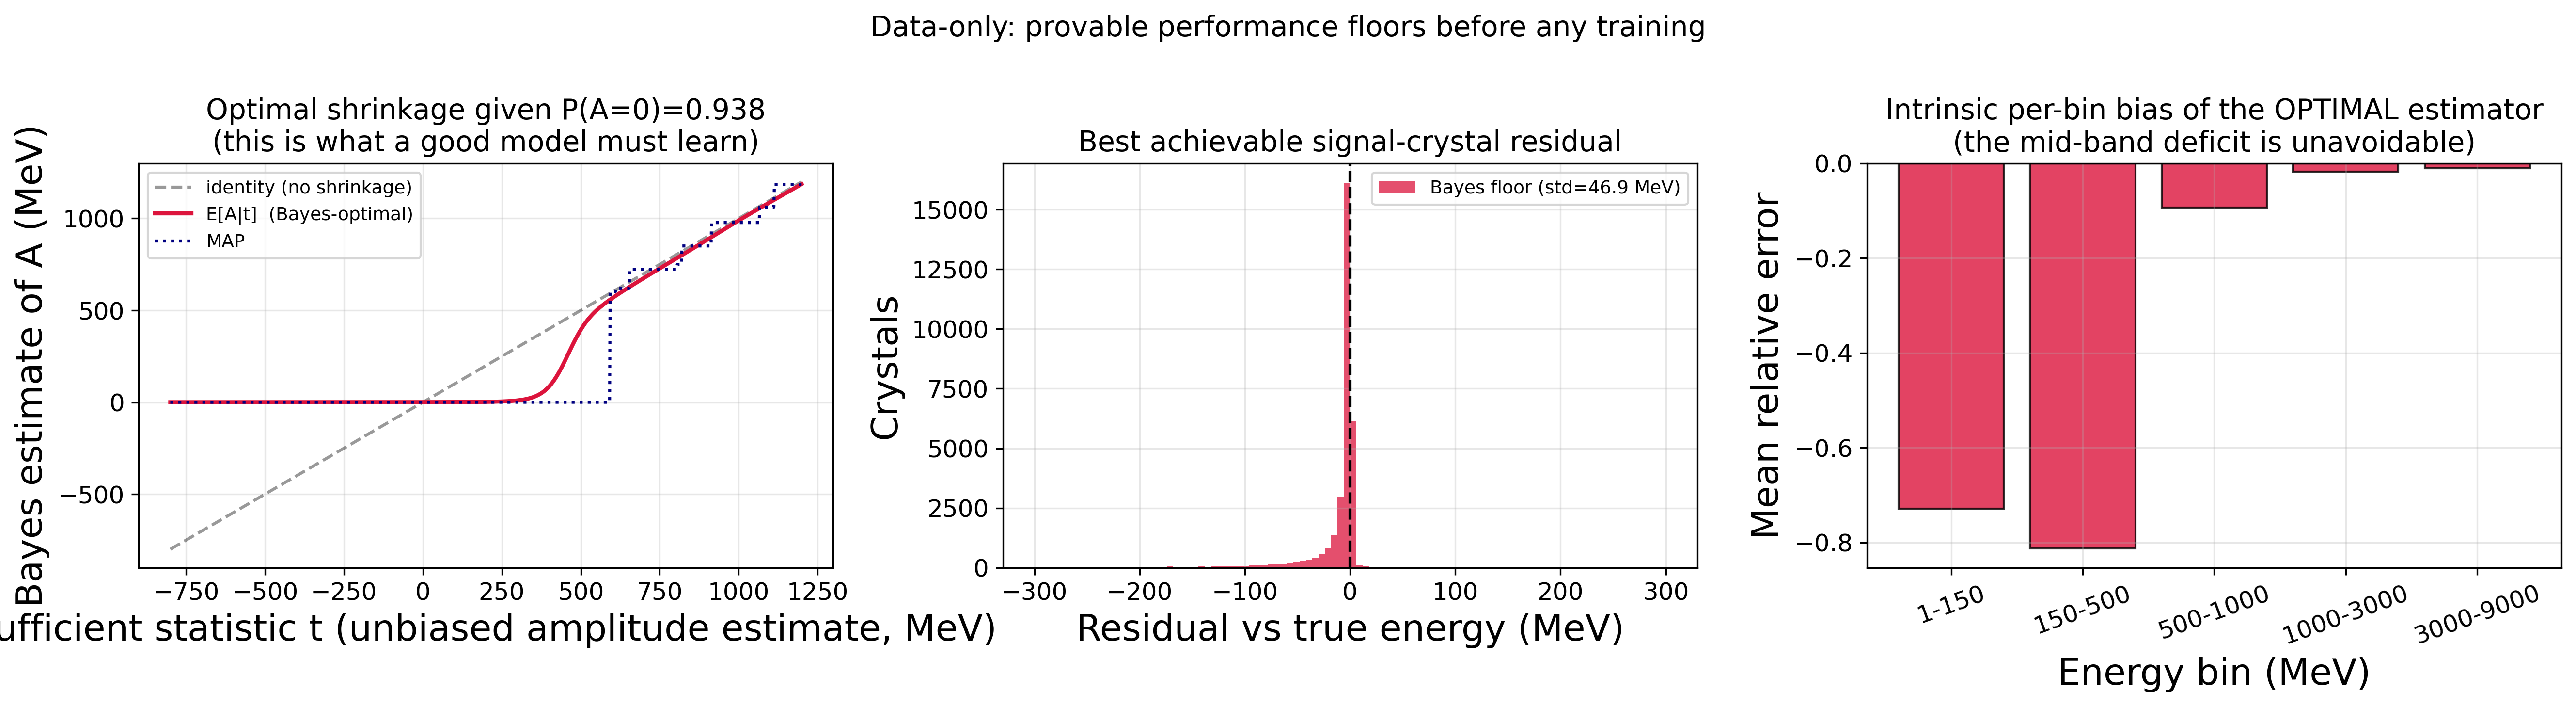

In [24]:
# ── Data-only: what is the BEST any model could possibly do on this dataset? ──
# Run this BEFORE training. No model, no GPU -- pure NumPy on data already
# prepared above, seconds to run.
#
# For x = A*S(t) + n with a KNOWN template S and KNOWN Gaussian noise covariance,
# the whitened matched-filter statistic
#
#     t = (W x . W S) / ||W S||^2 ,      W = L10^-1        (Cell 8)
#
# is a SUFFICIENT statistic for the amplitude A: the full 10-sample waveform
# carries no information about A beyond this single scalar. Two consequences,
# both of which set hard targets rather than heuristic ones:
#
#   1. Cramer-Rao: no UNBIASED estimator can have std below noise_amp/||W S||.
#   2. E[A|t] under the true prior is Bayes-optimal for SQUARED error, so its
#      residual width is a floor that no architecture of any size can beat.
#      Our Huber loss (delta=1.0) sits entirely in its quadratic regime here
#      (normalised residuals ~1e-4 to 1e-2), so the network is effectively
#      trained on squared error and E[A|t] is the correct target -- NOT MAP,
#      which optimises 0-1 loss and emits hard zeros.
#
# The prior is built from the TRAIN split only and evaluated on val, so nothing
# here leaks. Covariance and template are known by construction in this
# synthetic study; in a real experiment they come from pedestal runs and MC, so
# this remains a fair baseline rather than an oracle.
#
# IMPORTANT for the pileup extension: with overlapping pulses the generative
# model becomes x = sum_i A_i*S(t - tau_i) + n, t is NO LONGER sufficient, and
# no closed form exists. Re-running this cell on pileup data is what converts
# "the model works" into "the model beats what analytic methods can do".

# ── The two floors ───────────────────────────────────────────────────────────
mm_Sw   = W10 @ signal_template[0, :, 0].cpu().numpy().astype(np.float64)
mm_nSw2 = float(mm_Sw @ mm_Sw)
mm_s    = float(noise_amp) / np.sqrt(mm_nSw2)      # std of the sufficient statistic

print("=== Hard floors for amplitude estimation on this dataset ===")
print(f"||W S||^2 = {mm_nSw2:.4f}")
print(f"Cramer-Rao bound (any UNBIASED estimator):  {mm_s:.2f} MeV")
print(f"Raw peak sample as an amplitude estimate:   {float(noise_amp):.2f} MeV")
print(f"  -> optimal linear filtering buys only {float(noise_amp)/mm_s:.2f}x. Anything beyond")
print(f"     that must come from BIAS (shrinkage toward the mostly-empty prior).")

# ── Sufficient statistic on the val split ────────────────────────────────────
mm_t_val    = ((X_noisy[val_idx].astype(np.float64) @ W10.T) @ mm_Sw) / mm_nSw2
mm_a_val    = signal_amp[val_idx].astype(np.float64)
mm_sig_val  = mm_a_val > 0
print(f"\nsufficient-statistic self-check on true-noise val crystals:")
print(f"  mean = {mm_t_val[~mm_sig_val].mean():+.3f} MeV (expect ~0), "
      f"std = {mm_t_val[~mm_sig_val].std():.2f} MeV (expect ~{mm_s:.0f})")

# ── Prior from the TRAIN split only ──────────────────────────────────────────
mm_a_tr  = signal_amp[train_idx].astype(np.float64)
mm_f0    = float((mm_a_tr == 0).mean())
mm_a_pos = mm_a_tr[mm_a_tr > 0]

MM_NBINS   = 12000
mm_edges   = np.linspace(0.0, mm_a_pos.max() * 1.001, MM_NBINS + 1)
mm_cnt, _  = np.histogram(mm_a_pos, bins=mm_edges)
mm_Ag      = 0.5 * (mm_edges[:-1] + mm_edges[1:])
mm_w       = mm_cnt / mm_cnt.sum()
mm_keep    = mm_w > 0
mm_Ag, mm_w = mm_Ag[mm_keep], mm_w[mm_keep]
print(f"\nprior: P(A==0) = {mm_f0:.5f} | {len(mm_a_pos):,} nonzero train crystals "
      f"-> {len(mm_Ag)} atoms at {mm_edges[1]-mm_edges[0]:.2f} MeV resolution "
      f"(<< the {mm_s:.0f} MeV kernel width, so binning is not the limit)")

# ── E[A|t] and MAP on a t-grid (both depend on t alone), then interpolate ─────
mm_tg  = np.linspace(-800.0, float(mm_a_pos.max()) + 800.0, 7000)
mm_i2s = 1.0 / (2.0 * mm_s * mm_s)
mm_mmse = np.empty_like(mm_tg)
mm_map  = np.empty_like(mm_tg)
for i in range(0, len(mm_tg), 200):
    tt = mm_tg[i:i+200][:, None]
    K  = np.exp(-((tt - mm_Ag[None, :]) ** 2) * mm_i2s)          # N(t; A, s^2), up to a constant
    num = (K * (mm_w * mm_Ag)[None, :]).sum(1)
    den_sig = (K * mm_w[None, :]).sum(1)
    k0  = np.exp(-(mm_tg[i:i+200] ** 2) * mm_i2s)                 # the delta-at-zero component
    mm_mmse[i:i+200] = (1.0 - mm_f0) * num / np.maximum(mm_f0 * k0 + (1.0 - mm_f0) * den_sig, 1e-300)
    post = (1.0 - mm_f0) * K * mm_w[None, :]
    jb   = post.argmax(1)
    mm_map[i:i+200] = np.where(mm_f0 * k0 >= post[np.arange(len(jb)), jb], 0.0, mm_Ag[jb])

# ── Evaluate the classical estimators on the val split ───────────────────────
mm_est = {
    "MMSE  E[A|t]  (Bayes floor)": np.interp(mm_t_val, mm_tg, mm_mmse),
    "MAP":                          np.interp(mm_t_val, mm_tg, mm_map),
    "whitened MF, clipped >=0":     np.maximum(mm_t_val, 0.0),
}
print(f"\n{'estimator':<30}{'r':>9}{'resid std':>11}{'mean res':>10}{'noise mean':>12}{'noise 95%':>11}")
print("-" * 83)
for nm, P in mm_est.items():
    res = P[mm_sig_val] - mm_a_val[mm_sig_val]
    r   = np.corrcoef(mm_a_val[mm_sig_val], P[mm_sig_val])[0, 1]
    print(f"{nm:<30}{r:>9.4f}{res.std():>11.2f}{res.mean():>10.2f}"
          f"{P[~mm_sig_val].mean():>12.4f}{np.percentile(np.abs(P[~mm_sig_val]), 95):>11.4f}")

mm_bayes_floor = float((mm_est["MMSE  E[A|t]  (Bayes floor)"][mm_sig_val] - mm_a_val[mm_sig_val]).std())
print(f"\n>>> BAYES FLOOR for this dataset: {mm_bayes_floor:.2f} MeV residual std <<<")
print(f"    Denoising factor at that floor: {float(noise_amp)/mm_bayes_floor:.2f}x")
print("    No model of any size can beat this row. Compare any trained model against")
print("    it: a tie means the dataset has no headroom left and further architecture or")
print("    loss tuning cannot help -- only changing the dataset can.")

# ── Which bins are intrinsically hard, before any model is involved? ─────────
mm_bins = [(1, 150), (150, 500), (500, 1000), (1000, 3000), (3000, 9000)]
mm_floor_bin = {}
print(f"\n=== Mean relative error achieved by the BAYES-OPTIMAL estimator ===")
print(f"{'band (MeV)':>14}{'N':>9}{'MMSE':>9}{'MAP':>9}")
for lo, hi in mm_bins:
    m = mm_sig_val & (mm_a_val > lo) & (mm_a_val < hi)
    if m.sum() == 0:
        continue
    q  = ((mm_est["MMSE  E[A|t]  (Bayes floor)"][m] - mm_a_val[m]) / mm_a_val[m]).mean()
    pq = ((mm_est["MAP"][m] - mm_a_val[m]) / mm_a_val[m]).mean()
    mm_floor_bin[(lo, hi)] = q
    print(f"{lo:>6}-{hi:<7}{m.sum():>9,}{q:>9.2f}{pq:>9.2f}")
print("  A large negative value here is NOT a model defect -- it is the optimal")
print("  hedge given that most channels are empty. Any model matching these numbers")
print("  is behaving correctly, not failing.")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
mm_z = mm_tg <= 1200
ax.plot(mm_tg[mm_z], mm_tg[mm_z], 'k--', alpha=0.4, label='identity (no shrinkage)')
ax.plot(mm_tg[mm_z], mm_mmse[mm_z], color='crimson', lw=2, label='E[A|t]  (Bayes-optimal)')
ax.plot(mm_tg[mm_z], mm_map[mm_z],  color='navy', lw=1.5, ls=':', label='MAP')
ax.set_xlabel("sufficient statistic t (unbiased amplitude estimate, MeV)")
ax.set_ylabel("Bayes estimate of A (MeV)")
ax.set_title(f"Optimal shrinkage given P(A=0)={mm_f0:.3f}\n(this is what a good model must learn)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(mm_est["MMSE  E[A|t]  (Bayes floor)"][mm_sig_val] - mm_a_val[mm_sig_val],
        bins=100, range=(-300, 300), color='crimson', alpha=0.75,
        label=f'Bayes floor (std={mm_bayes_floor:.1f} MeV)')
ax.axvline(0, color='black', ls='--')
ax.set_xlabel("Residual vs true energy (MeV)"); ax.set_ylabel("Crystals")
ax.set_title("Best achievable signal-crystal residual")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
mm_lab = [f"{lo}-{hi}" for (lo, hi) in mm_floor_bin]
ax.bar(range(len(mm_lab)), list(mm_floor_bin.values()), color='crimson',
       edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(range(len(mm_lab))); ax.set_xticklabels(mm_lab, rotation=20)
ax.set_xlabel("Energy bin (MeV)"); ax.set_ylabel("Mean relative error")
ax.set_title("Intrinsic per-bin bias of the OPTIMAL estimator\n(the mid-band deficit is unavoidable)")
ax.grid(True, alpha=0.3)

fig.suptitle("Data-only: provable performance floors before any training", fontsize=14)
fig.tight_layout()
plt.show()


In [21]:
def train(beta=0.0005, free_bits=0.05):
    model.train()
    total_loss  = 0.0
    total_recon = 0.0
    total_peak  = 0.0
    total_kl    = 0.0

    for X_batch, Y_batch, amp_batch, mf_batch in train_loader:
        X_batch   = X_batch.to(device, non_blocking=True)
        Y_batch   = Y_batch.to(device, non_blocking=True)
        amp_batch = amp_batch.to(device, non_blocking=True)
        mf_batch  = mf_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred, mu, log_var = model(X_batch, mf_batch)
        loss, recon_loss, peak_loss, kl_loss = vae_loss(
            pred, Y_batch, mu, log_var, amp_batch, beta=beta, free_bits=free_bits)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        total_recon += recon_loss.item()
        total_peak  += peak_loss.item()
        total_kl    += kl_loss.item()

    n = len(train_loader)
    print(f"Train Recon:Peak:KL Loss ---> {total_recon/n:.6f}:{total_peak/n:.6f}:{total_kl/n:.6f}")
    return total_loss/n, total_recon/n, total_peak/n, total_kl/n

In [22]:
def validate(beta=0.0005, free_bits=0.05):
    model.eval()
    total_loss  = 0.0
    total_recon = 0.0
    total_peak  = 0.0
    total_kl    = 0.0

    with torch.no_grad():
        for X_batch, Y_batch, amp_batch, mf_batch in val_loader:
            X_batch   = X_batch.to(device, non_blocking=True)
            Y_batch   = Y_batch.to(device, non_blocking=True)
            amp_batch = amp_batch.to(device, non_blocking=True)
            mf_batch  = mf_batch.to(device, non_blocking=True)

            pred, mu, log_var = model(X_batch, mf_batch)
            loss, recon_loss, peak_loss, kl_loss = vae_loss(
                pred, Y_batch, mu, log_var, amp_batch, beta=beta, free_bits=free_bits)

            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_peak  += peak_loss.item()
            total_kl    += kl_loss.item()

    n = len(val_loader)
    print(f"Val   Recon:Peak:KL Loss ---> {total_recon/n:.6f}:{total_peak/n:.6f}:{total_kl/n:.6f}")
    return total_loss/n, total_recon/n, total_peak/n, total_kl/n

In [23]:
import os
import time

save_directory = "LSTM_Models"
os.makedirs(save_directory, exist_ok=True)
print(f"Models will be saved to: {save_directory}/")

print("Run: tensorboard --logdir=runs")

Models will be saved to: LSTM_Models/
Run: tensorboard --logdir=runs


In [24]:
def beta_schedule(epoch, total_epochs, beta_max=0.0005, warmup_frac=0.35):
    warmup_epochs = max(1, int(total_epochs * warmup_frac))
    if epoch >= warmup_epochs:
        return beta_max
    return beta_max * (epoch / warmup_epochs)

In [ ]:
# ── Smoke test: can the model overfit a single batch? ──────────────────────
# Fast (seconds, not the ~1hr/10-epoch full run), catches wiring bugs -- dead
# heads, broken gradients, shape/dtype errors, NaNs -- before committing GPU
# time. If a model can't drive loss near zero on ONE repeated batch within a
# few hundred steps, something upstream is broken; hyperparameter tuning on
# the full run won't fix it.
#
# Self-contained on purpose: hardcodes the same architecture hyperparameters
# used in `best` below, rather than depending on that cell having run first.
smoke_hparams = {"hidden_dim": 128, "latent_dim": 8, "num_layers": 3}

X_smoke, Y_smoke, amp_smoke, mf_smoke = next(iter(train_loader))
X_smoke   = X_smoke.to(device)
Y_smoke   = Y_smoke.to(device)
amp_smoke = amp_smoke.to(device)
mf_smoke  = mf_smoke.to(device)

print(f"Batch target stats -> mean={Y_smoke.mean().item():.4f}, "
      f"std={Y_smoke.std().item():.4f}, max|target|={Y_smoke.abs().max().item():.4f}")

smoke_model = VAE(
    input_dim=1, hidden_dim=smoke_hparams["hidden_dim"], latent_dim=smoke_hparams["latent_dim"],
    num_layers=smoke_hparams["num_layers"], dropout=0.0            # dropout off for a clean overfit test
).to(device)
smoke_model.set_signal_template(signal_template)
smoke_opt = torch.optim.Adam(smoke_model.parameters(), lr=1e-3)

smoke_model.train()
for step in range(300):
    smoke_opt.zero_grad()
    pred, mu, log_var = smoke_model(X_smoke, mf_smoke)
    loss, recon, peak, kl = vae_loss(pred, Y_smoke, mu, log_var, amp_smoke, beta=0.0)  # beta=0: isolate reconstruction
    loss.backward()
    smoke_opt.step()
    if step % 50 == 0 or step == 299:
        print(f"step {step:4d} | loss {loss.item():.6f} | recon {recon.item():.6f} | peak {peak.item():.6f}")

print("\nPASS if recon/peak loss dropped by >=10-100x from step 0 toward ~0.")
print("FAIL (flat or NaN) means a wiring bug -- do not proceed to the full training loop yet.")

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
python(72821) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72822) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72831) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Batch target stats -> mean=0.0014, std=0.0343, max|target|=1.3256
step    0 | loss 0.627033 | recon 0.250732 | peak 0.752603
step   50 | loss 0.067428 | recon 0.027631 | peak 0.079593
step  100 | loss 0.067200 | recon 0.027513 | peak 0.079374
step  150 | loss 0.067317 | recon 0.027561 | peak 0.079512
step  200 | loss 0.066543 | recon 0.027213 | peak 0.078661
step  250 | loss 0.067418 | recon 0.027639 | peak 0.079557
step  299 | loss 0.068422 | recon 0.028126 | peak 0.080592

PASS if recon/peak loss dropped by >=10-100x from step 0 toward ~0.
FAIL (flat or NaN) means a wiring bug -- do not proceed to the full training loop yet.


: 

In [ ]:
# ── Hyperparameters with regularization ──────────────────────────────────
best = {
    "hidden_dim":  128,
    "latent_dim":  8,
    "num_layers":  3,
    "dropout":     0.25,      # Fix 3: Increased dropout from 0.16 to 0.25
    "lr":          0.0005,
    "beta_max":    0.0005,
    "warmup_frac": 0.35,
}
print("Using hyperparameters:", best)

model = VAE(
    input_dim=1,
    hidden_dim=best["hidden_dim"],
    latent_dim=best["latent_dim"],
    num_layers=best["num_layers"],
    dropout=best["dropout"]
).to(device)

# Set physics template on VAE model (handles DataParallel unwrapping)
m = model.module if isinstance(model, nn.DataParallel) else model
m.set_signal_template(signal_template)
print("Signal template set:", m.signal_template.shape)
print("Peak at t=5:", m.signal_template[0, 5, 0].item())

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

# Weight init
# Fix: the LSTM-style orthogonal/forget-gate-bias init must only apply to the
# encoder/decoder LSTM parameters. Applying it to every parameter zeroed out
# context_norm's LayerNorm weight (collapsing the VAE bottleneck input to a
# constant) and corrupted fc_mu/fc_log_var/fc_h0/fc_c0 biases.
with torch.no_grad():
    params = model.module.named_parameters() if isinstance(model, nn.DataParallel) else model.named_parameters()
    for name, param in params:
        if 'encoder' in name or 'decoder' in name:
            if 'weight_hh' in name:
                torch.nn.init.orthogonal_(param)
            elif 'weight_ih' in name:
                torch.nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                torch.nn.init.zeros_(param)
                n = param.shape[0] // 4
                param[n:2 * n].fill_(1.0)   # forget-gate bias trick
        elif param.dim() >= 2:
            torch.nn.init.xavier_uniform_(param)
        # else: leave other 1-D params (LayerNorm weight/bias, head biases)
        # at their PyTorch defaults instead of zeroing/corrupting them.

# Fix 2: Add weight_decay=1e-5 to Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# ── Training run with Early Stopping ──────────────────────────────────────
epochs       = 100
patience     = 25      # bumped from 15: val loss is noisy epoch-to-epoch (see loss
                        # curves), so give ReduceLROnPlateau (patience=10) room to
                        # actually kick in and be evaluated before we give up
no_improve   = 0

# ── Model selection uses a BETA-INDEPENDENT metric ────────────────────────────
# BUGFIX. Selection previously used val_total = recon + 0.5*peak + beta*KL, but
# beta ramps 0 -> beta_max over warmup_frac of the run while KL falls. Later
# epochs therefore carry a large penalty unrelated to reconstruction quality,
# and early epochs win by default. In the preceding run this selected epoch 1
# (recon+0.5*peak = 0.000374) over epoch 10 (0.000271) -- a 38% worse
# reconstruction -- and tripped early stopping at 26 instead of letting the run
# continue, purely as an artefact of the ramp. Selecting on recon + 0.5*peak
# removes beta from the comparison entirely, so epochs are ranked on the
# quantity we actually care about.
def selection_metric(recon, peak):
    return recon + 0.5 * peak

train_total_losses   = []
val_total_losses     = []
train_recon_losses   = []
val_recon_losses     = []
train_peak_losses    = []
val_peak_losses      = []
train_kl_losses      = []
val_kl_losses        = []
beta_history         = []
lr_history           = []
val_select_history   = []   # beta-independent selection metric, per epoch

best_val_loss = float('inf')     # now holds the best BETA-INDEPENDENT score
start_epoch   = 1

# ── Resume-from-checkpoint ────────────────────────────────────────────────────
# The previous run reached its best score at the LAST epoch (69/70) and was cut
# off by the session limit, not by convergence -- so it was still improving when
# it died. Saving only model weights is not enough to continue: the optimizer
# moments, the LR-scheduler state (which had already stepped down to 6.3e-5),
# the epoch counter (beta_schedule depends on it), the early-stopping counter
# and the loss histories all have to come back too. RESUME_PATH is rewritten
# every epoch so a killed session loses at most one epoch of work.
RESUME_PATH = os.path.join(save_directory, "resume_last.pt")

def save_resume(epoch):
    torch.save({
        "epoch":          epoch,
        "model":          (model.module if isinstance(model, nn.DataParallel) else model).state_dict(),
        "optimizer":      optimizer.state_dict(),
        "scheduler":      scheduler.state_dict(),
        "best_val_loss":  best_val_loss,
        "no_improve":     no_improve,
        "history": {
            "train_total": train_total_losses, "val_total": val_total_losses,
            "train_recon": train_recon_losses, "val_recon": val_recon_losses,
            "train_peak":  train_peak_losses,  "val_peak":  val_peak_losses,
            "train_kl":    train_kl_losses,    "val_kl":    val_kl_losses,
            "beta":        beta_history,       "lr":        lr_history,
            "val_select":  val_select_history,
        },
    }, RESUME_PATH)

RESUME = True     # set False to force a fresh run even if a checkpoint exists

if RESUME and os.path.exists(RESUME_PATH):
    ck = torch.load(RESUME_PATH, map_location=device)
    try:
        (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optimizer"])
        scheduler.load_state_dict(ck["scheduler"])
        best_val_loss = ck["best_val_loss"]
        no_improve    = ck["no_improve"]
        h = ck["history"]
        train_total_losses = h["train_total"]; val_total_losses = h["val_total"]
        train_recon_losses = h["train_recon"]; val_recon_losses = h["val_recon"]
        train_peak_losses  = h["train_peak"];  val_peak_losses  = h["val_peak"]
        train_kl_losses    = h["train_kl"];    val_kl_losses    = h["val_kl"]
        beta_history       = h["beta"];        lr_history       = h["lr"]
        val_select_history = h["val_select"]
        start_epoch = ck["epoch"] + 1
        print(f"[RESUMED] from epoch {ck['epoch']} -> continuing at {start_epoch}/{epochs}")
        print(f"          best ValSel so far {best_val_loss:.6f} | no_improve {no_improve}"
              f" | lr {optimizer.param_groups[0]['lr']:.6g}")
        if start_epoch > epochs:
            print(f"          NOTE: already at/past epoch {epochs}. Raise `epochs` to train further.")
    except (RuntimeError, KeyError) as e:
        # Architecture or history schema changed since this checkpoint was saved,
        # so state_dict/history keys no longer match. Can't resume; fall back to
        # a fresh run rather than crashing mid-setup.
        print(f"[RESUME FAILED] incompatible checkpoint ({e}).")
        print("          Starting a FRESH run instead.")
        start_epoch = 1
else:
    print(f"[FRESH RUN] no resume file at {RESUME_PATH}")

start_time       = time.time()
block_start_time = time.time()

for epoch in range(start_epoch, epochs + 1):

    beta = beta_schedule(epoch, epochs, beta_max=best["beta_max"], warmup_frac=best["warmup_frac"])

    train_total, train_recon, train_peak, train_kl = train(beta=beta)
    val_total,   val_recon,   val_peak,   val_kl   = validate(beta=beta)

    val_select = selection_metric(val_recon, val_peak)   # beta-independent
    scheduler.step(val_select)
    current_lr = optimizer.param_groups[0]['lr']

    train_total_losses.append(train_total)
    val_total_losses.append(val_total)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_peak_losses.append(train_peak)
    val_peak_losses.append(val_peak)
    train_kl_losses.append(train_kl)
    val_kl_losses.append(val_kl)
    beta_history.append(beta)
    lr_history.append(current_lr)


    # Fix 5: Early stopping tracking
    val_select_history.append(val_select)

    if val_select < best_val_loss:
        best_val_loss = val_select
        no_improve    = 0
        save_path = os.path.join(
            save_directory,
            f"Epoch_{epoch}_TrainLoss_{train_total:.4f}_ValSel_{val_select:.6f}.pt"
        )
        torch.save(
            model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            save_path
        )
    else:
        no_improve += 1

    print(
        f"Epoch {epoch:4d} | beta: {beta:.6f} | lr: {current_lr:.6f} | "
        f"Train Total: {train_total:.6f} | "
        f"Val Total: {val_total:.6f} | "
        f"ValSel: {val_select:.6f}{'  <-- best' if no_improve == 0 else ''}"
    )

    save_resume(epoch)   # rewritten every epoch: a killed session loses <= 1 epoch

    if epoch % 10 == 0:
        elapsed_block   = time.time() - block_start_time
        total_elapsed   = time.time() - start_time
        print(f"\nTime for epochs {epoch-9}-{epoch}: {elapsed_block/60:.2f} minutes")
        print(f"Total training time till epoch {epoch}: {total_elapsed/60:.2f} minutes\n")
        block_start_time = time.time()

    if no_improve >= patience:
        print(f"\n[Early Stopping Triggered] Beta-independent val metric (recon + 0.5*peak) "
              f"did not improve for {patience} consecutive epochs. Stopping at epoch {epoch}.\n")
        break



Using hyperparameters: {'hidden_dim': 128, 'latent_dim': 8, 'num_layers': 3, 'dropout': 0.25, 'lr': 0.0005, 'beta_max': 0.0005, 'warmup_frac': 0.35}
Signal template set: torch.Size([1, 10, 1])
Peak at t=5: 1.0
[FRESH RUN] no resume file at LSTM_Models/resume_last.pt


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
python(73006) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(73007) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(73008) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(73009) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
# ── Sanity check: verify amp_head and shape_head outputs ─────────────────────
model.eval()

# Take one batch from val_loader
for X_b, Y_b, amp_b, mf_b in val_loader:
    X_b  = X_b.to(device)
    mf_b = mf_b.to(device)
    break

with torch.no_grad():
    # Get intermediate outputs manually
    m = model.module if isinstance(model, nn.DataParallel) else model

    enc_out, (h_n, _) = m.encoder(X_b)
    context = torch.cat([h_n[-2], h_n[-1]], dim=1)
    context = m.context_norm(context)
    mf_b_scaled = torch.sign(mf_b) * torch.log1p(torch.abs(mf_b))   # match forward()'s squash exactly
    context = torch.cat([context, mf_b_scaled.view(-1, 1)], dim=1)

    mu      = m.fc_mu(context)
    log_var = m.fc_log_var(context)
    z       = mu  # deterministic during eval

    h0 = m.fc_h0(z).view(-1, m.num_layers, m.hidden_dim).permute(1, 0, 2).contiguous()
    c0 = m.fc_c0(z).view(-1, m.num_layers, m.hidden_dim).permute(1, 0, 2).contiguous()

    seq_len    = X_b.shape[1]
    batch_size = X_b.shape[0]
    time_steps = torch.linspace(0, 1, steps=seq_len, device=device)
    time_input = time_steps.view(1, seq_len, 1).repeat(batch_size, 1, 1)
    z_expanded = z.unsqueeze(1).repeat(1, seq_len, 1)
    dec_input  = torch.cat([time_input, z_expanded], dim=-1)

    dec_out, _ = m.decoder(dec_input, (h0, c0))

    # Extract amp and shape separately
    amplitude     = torch.nn.functional.softplus(m.amp_head(dec_out[:, 5:6, :]))   # (batch, 1, 1)
    shape_correct = m.shape_head(dec_out)                          # (batch, 10, 1)
    out           = amplitude * (signal_template + shape_correct)  # (batch, 10, 1)

# Convert to numpy
amplitude_np     = amplitude[:, 0, 0].cpu().numpy()
shape_correct_np = shape_correct[:, :, 0].cpu().numpy()
out_np           = out[:, :, 0].cpu().numpy()
# The loader now supplies the WHITENED waveform (Cell 12), so undo the change of
# basis for plotting -- otherwise the "noisy" trace shown is not the readout.
# X_norm = X_w @ L10.T  (inverse of X_w = X_norm @ W10.T)
X_np             = (X_b[:, :, 0].cpu().numpy() @ L10.T)
Y_np             = Y_b[:, :, 0].cpu().numpy()
amp_np           = amp_b.cpu().numpy()
template_np      = signal_template[:, :, 0].cpu().numpy()

print("=== Shape Check ===")
print(f"amplitude shape:      {amplitude.shape}      → should be (batch, 1, 1)")
print(f"shape_correct shape:  {shape_correct.shape}  → should be (batch, 10, 1)")
print(f"out shape:            {out.shape}             → should be (batch, 10, 1)")
print(f"amplitude min/max:    {amplitude_np.min():.4f} / {amplitude_np.max():.4f}")
print(f"shape_correct range:  {shape_correct_np.min():.4f} / {shape_correct_np.max():.4f}")

print("\n=== Value Check (first 5 crystals) ===")
for i in range(5):
    print(f"Crystal {i}: true_amp={amp_np[i]:.1f} MeV | "
          f"pred_amplitude={amplitude_np[i]:.4f} | "
          f"shape_correction_peak={shape_correct_np[i, 5]:.4f}")

# ── Discrimination check: is amp_head actually using per-sample info? ────────
# The softplus-vs-leaky_relu smoke test earlier showed amp_head's pre-activation
# collapsing to an EXACT constant across an entire batch when beta=0 (no KL
# pressure to keep the encoder's posterior sample-dependent). Real training uses
# beta>0 from epoch 1, but this could still happen -- check for it directly.
print("\n=== Discrimination check: does amp_head vary across samples? ===")
amp_std = amplitude_np.std()
n_unique = len(np.unique(amplitude_np.round(4)))
print(f"amplitude std across batch:        {amp_std:.6f}  (want clearly > 0)")
print(f"amplitude unique values (4dp):     {n_unique} / {len(amplitude_np)} samples")
mu_std = mu.std(dim=0).mean().item()
print(f"latent mu std across batch (mean over dims): {mu_std:.6f}  (want clearly > 0 -- else posterior collapse)")
if amp_std < 1e-4 or n_unique <= 2:
    print("WARNING: amp_head output is (near-)constant across the batch -- "
          "posterior/output collapse, model is ignoring per-sample input.")
else:
    print("OK: amp_head output varies meaningfully across samples.")

# ── Plot 1: amplitude predictions vs true energy ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sig_mask_batch = amp_np > 0
axes[0].scatter(amp_np[sig_mask_batch], amplitude_np[sig_mask_batch],
                alpha=0.5, s=10, color='blue')
axes[0].set_xlabel("True Energy (MeV)")
axes[0].set_ylabel("Predicted Amplitude (normalized)")
axes[0].set_title("amp_head output vs True Energy\n(should correlate after training)")
axes[0].grid(True, alpha=0.3)

# ── Plot 2: shape corrections vs signal template ──────────────────────────────
time_axis = np.arange(10)
mean_shape_sig   = shape_correct_np[sig_mask_batch].mean(axis=0)
mean_shape_noise = shape_correct_np[~sig_mask_batch].mean(axis=0)

axes[1].plot(time_axis, template_np[0],       'k-',  label='S(t) template',     linewidth=2)
axes[1].plot(time_axis, mean_shape_sig,        'b--', label='Mean δS(t) signal', linewidth=1.5)
axes[1].plot(time_axis, mean_shape_noise,      'r--', label='Mean δS(t) noise',  linewidth=1.5)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel("Time Sample")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("shape_head corrections vs S(t)\n(δS should be small after training)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Plot 3: full output for a few of the highest-energy crystals in this batch ─
# Previously required amp>1000 MeV specifically, which could be empty depending
# on which random batch got drawn (leaving this panel blank) -- fall back to the
# top-3 highest-energy crystals actually present so it is never empty.
high_sig = np.where(amp_np > 1000)[0]
high_sig = high_sig[:3] if len(high_sig) >= 3 else np.argsort(amp_np)[::-1][:3]
for idx in high_sig:
    axes[2].plot(time_axis, X_np[idx],   '--', alpha=0.4, label=f'Noisy (E={amp_np[idx]:.0f}MeV)')
    axes[2].plot(time_axis, Y_np[idx],   '-',  alpha=0.7, label=f'Target')
    axes[2].plot(time_axis, out_np[idx], '-o', alpha=0.9, label=f'VAE output')

axes[2].axvline(x=5, color='orange', linestyle=':', alpha=0.5, label='Peak t=5')
axes[2].set_xlabel("Time Sample")
axes[2].set_ylabel("Normalized Amplitude")
axes[2].set_title("Full Reconstruction\n(random at init, should match target after training)")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

fig.suptitle("Sanity Check: amp_head and shape_head", fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# ── Physics-aware output head diagnostics (full val set, post-training) ──────
model.eval()
m = model.module if isinstance(model, nn.DataParallel) else model

all_amp_pred, all_amp_true = [], []
all_shape_corr = []
all_is_signal = []

with torch.no_grad():
    batch_i = 0
    for X_b, Y_b, amp_b, mf_b in val_loader:
        X_b  = X_b.to(device)
        mf_b = mf_b.to(device)

        enc_out, (h_n, _) = m.encoder(X_b)
        context = m.context_norm(torch.cat([h_n[-2], h_n[-1]], dim=1))
        mf_b_scaled = torch.sign(mf_b) * torch.log1p(torch.abs(mf_b))   # match forward()'s squash exactly
        context = torch.cat([context, mf_b_scaled.view(-1, 1)], dim=1)
        mu = m.fc_mu(context)
        z = mu  # deterministic eval

        h0 = m.fc_h0(z).view(-1, m.num_layers, m.hidden_dim).permute(1, 0, 2).contiguous()
        c0 = m.fc_c0(z).view(-1, m.num_layers, m.hidden_dim).permute(1, 0, 2).contiguous()

        seq_len, batch_size = X_b.shape[1], X_b.shape[0]
        time_steps = torch.linspace(0, 1, steps=seq_len, device=device)
        time_input = time_steps.view(1, seq_len, 1).repeat(batch_size, 1, 1)
        z_expanded = z.unsqueeze(1).repeat(1, seq_len, 1)
        dec_input = torch.cat([time_input, z_expanded], dim=-1)

        dec_out, _ = m.decoder(dec_input, (h0, c0))
        amplitude = torch.nn.functional.softplus(m.amp_head(dec_out[:, 5:6, :]))   # (batch,1,1)
        shape_corr = m.shape_head(dec_out)                         # (batch,10,1)

        all_amp_pred.append(amplitude[:, 0, 0].cpu().numpy())
        all_amp_true.append(amp_b.numpy())
        all_shape_corr.append(shape_corr[:, :, 0].cpu().numpy())
        all_is_signal.append((amp_b.numpy() > 0))
        batch_i += 1

amp_pred_norm = np.concatenate(all_amp_pred)     # normalized amp_head output (target = true_energy/GLOBAL_SCALE)
amp_true      = np.concatenate(all_amp_true)     # true MeV energy
shape_corr    = np.concatenate(all_shape_corr)   # (N,10) δS(t)
is_signal     = np.concatenate(all_is_signal)

# ── Physical recovery ─────────────────────────────────────────────────────────
# amp_head now regresses true_energy/GLOBAL_SCALE directly (Cell 12 fix), so
# converting back to MeV is just multiplying by the fixed, known GLOBAL_SCALE
# constant -- no leakage, since GLOBAL_SCALE isn't derived from this sample and
# is available at real inference time too.
amp_pred_phys = amp_pred_norm * GLOBAL_SCALE

# ── 0. Is amp_head close to its actual training target (energy/GLOBAL_SCALE)? ─
target_norm = amp_true / GLOBAL_SCALE
print("=== amp_head vs its actual training target (normalized space) ===")
print(f"Signal crystals — mean |amp_pred_norm - target_norm|: "
      f"{np.abs(amp_pred_norm[is_signal] - target_norm[is_signal]).mean():.4f}")
print(f"Noise crystals  — mean amp_pred_norm: {amp_pred_norm[~is_signal].mean():.4f} (target 0.0)")

# ── 1. amp_head: does it recover true energy at REAL inference conditions? ───
sig_amp_true = amp_true[is_signal]
sig_amp_pred = amp_pred_phys[is_signal]
resid = sig_amp_pred - sig_amp_true
r = np.corrcoef(sig_amp_true, sig_amp_pred)[0, 1]

# ── Relative error: restrict to a physically meaningful true energy ──────────
# `is_signal` is just amp>0, which includes shower-tail crystals with true
# energy down near 1e-5 MeV. Dividing by such a tiny denominator explodes the
# relative error regardless of how good the prediction is -- a metric
# artifact, not a model failure -- and dominates both the plot's x-axis scale
# and any MEAN-based summary. Report both so the distortion is visible.
MIN_E_FOR_RELERR = 1.0  # MeV
relerr_mask   = sig_amp_true >= MIN_E_FOR_RELERR
excluded_frac = 1.0 - relerr_mask.mean()

rel_res_all = resid / sig_amp_true                            # includes near-zero-denominator blowups
rel_res     = resid[relerr_mask] / sig_amp_true[relerr_mask]   # meaningful subset

print("\n=== amp_head diagnostics (signal crystals only) ===")
print(f"Pearson r (true vs pred energy):      {r:.4f}")
print(f"Mean residual (MeV):                  {resid.mean():.3f}")
print(f"Residual std (MeV):                   {resid.std():.3f}")
print(f"\n[Unfiltered] median relative error:      {np.median(np.abs(rel_res_all))*100:.2f}%  "
      f"(distorted by {excluded_frac*100:.1f}% of 'signal' crystals with true E < {MIN_E_FOR_RELERR} MeV)")
print(f"[Filtered, E >= {MIN_E_FOR_RELERR} MeV] median relative error: {np.median(np.abs(rel_res))*100:.2f}%  (median |Δ|/E)")

# amp_head on noise crystals should be near zero
noise_amp_pred = amp_pred_phys[~is_signal]
print(f"\nNoise-crystal amp_head output — mean: {noise_amp_pred.mean():.4f} MeV, "
      f"95th pct: {np.percentile(np.abs(noise_amp_pred), 95):.4f} MeV (want ~0)")

# ── 2. shape_head: is it a *small correction*, not doing the heavy lifting? ──
mean_abs_corr_sig   = np.abs(shape_corr[is_signal]).mean()
mean_abs_corr_noise = np.abs(shape_corr[~is_signal]).mean()
template_peak = 1.0  # template normalized to peak 1.0 at t=5

print("\n=== shape_head diagnostics ===")
print(f"Mean |δS(t)| on signal crystals:  {mean_abs_corr_sig:.4f}  "
      f"(fraction of template peak: {mean_abs_corr_sig/template_peak*100:.1f}%)")
print(f"Mean |δS(t)| on noise crystals:   {mean_abs_corr_noise:.4f}")
print("If mean |δS(t)| on signal crystals is a large fraction of the template peak, "
      "shape_head is compensating for a bad template/amp_head rather than making a small correction.")

# ── Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(sig_amp_true, sig_amp_pred, alpha=0.3, s=8, color='blue')
lim = max(sig_amp_true.max(), sig_amp_pred.max())
axes[0].plot([0, lim], [0, lim], 'k--', label='Ideal')
axes[0].set_xlabel("True Energy (MeV)")
axes[0].set_ylabel("Predicted Energy (amp_head, MeV)")
axes[0].set_title(f"amp_head recovery (r={r:.3f})")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Even filtered to E>=1MeV, a handful of near-threshold crystals (small true
# E, modest absolute residual) can have relative error in the hundreds of
# percent -- matplotlib's default auto-scaling stretches the x-axis to fit
# them, squashing the informative bulk into an unreadable spike. Clip the
# DISPLAY range only (data/stats above are unaffected) so the plot is legible.
REL_ERR_DISPLAY_RANGE = 3.0  # +/-300%
frac_outside_display = (np.abs(rel_res) > REL_ERR_DISPLAY_RANGE).mean()
axes[1].hist(rel_res, bins=60, range=(-REL_ERR_DISPLAY_RANGE, REL_ERR_DISPLAY_RANGE), alpha=0.7, color='crimson')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel("Relative energy error (pred-true)/true")
axes[1].set_title(f"amp_head relative error distribution\n(E >= {MIN_E_FOR_RELERR} MeV only, "
                   f"{frac_outside_display*100:.1f}% outside +/-{REL_ERR_DISPLAY_RANGE*100:.0f}% not shown)")
axes[1].grid(True, alpha=0.3)

time_axis = np.arange(10)
axes[2].plot(time_axis, shape_corr[is_signal].mean(axis=0), 'b-', label='Mean δS(t) signal')
axes[2].plot(time_axis, shape_corr[~is_signal].mean(axis=0), 'r-', label='Mean δS(t) noise')
axes[2].fill_between(time_axis,
                      shape_corr[is_signal].mean(axis=0) - shape_corr[is_signal].std(axis=0),
                      shape_corr[is_signal].mean(axis=0) + shape_corr[is_signal].std(axis=0),
                      alpha=0.2, color='blue')
axes[2].axhline(0, color='gray', linestyle=':')
axes[2].set_xlabel("Time Sample")
axes[2].set_title("shape_head correction shape")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

fig.suptitle("Physics-aware output head diagnostics (full validation set)", fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# ── Does the model actually DENOISE -- residual before vs after ──────────────
# Recovery-accuracy metrics (r, relative error) don't distinguish "the raw
# signal already told you the answer" from "the model actually cleaned it
# up." This isolates the model's real noise-suppression contribution: compare
# the RAW noisy reading (literally the peak sample of X_noisy, no processing
# at all) against the VAE's denoised output, both measured against ground
# truth. Reuses amp_pred_phys / amp_true / is_signal / resid / n_used from
# the physics-aware diagnostics cell above -- run that first.

n_used = len(amp_pred_phys)   # val_loader drops the last partial batch
X_val_raw_peak = X_noisy[val_idx][:n_used, 5]   # already raw physical MeV -- no GLOBAL_SCALE needed (unlike the LSTM notebooks, X_noisy here was never divided by it)
naive_resid = X_val_raw_peak[is_signal] - amp_true[is_signal]   # "before": no denoising at all
vae_resid   = resid                                              # "after": already computed above

print("=== Denoising check: raw noisy reading vs VAE output, both vs ground truth ===")
print(f"Raw noisy reading    — std: {naive_resid.std():.2f} MeV  (mean: {naive_resid.mean():.2f})")
print(f"VAE denoised output  — std: {vae_resid.std():.2f} MeV  (mean: {vae_resid.mean():.2f})")
print(f"Noise reduction factor: {naive_resid.std() / vae_resid.std():.1f}x")

fig, ax = plt.subplots(figsize=(9, 5.5))
lim = 300  # MeV, display range -- both distributions have some tail beyond this
ax.hist(naive_resid, bins=100, range=(-lim, lim), alpha=0.5, color='gray',
        label=f'Raw noisy reading, no processing (std={naive_resid.std():.0f} MeV)')
ax.hist(vae_resid,   bins=100, range=(-lim, lim), alpha=0.7, color='crimson',
        label=f'VAE denoised output (std={vae_resid.std():.0f} MeV)')
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel("Residual vs true energy (MeV)")
ax.set_ylabel("Crystals")
ax.set_title(f"Denoising in action: {naive_resid.std()/vae_resid.std():.1f}x noise reduction\n"
             f"(raw reading vs VAE output, both measured against ground truth)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── Trained model vs the Bayes floor: is it learning more than prior shrinkage? ─
# The decisive control for this study, and the comparison a reviewer will ask
# for. Reuses the lookup tables built by the data-only Bayes-floor cell (mm_tg /
# mm_mmse / mm_map / mm_s), so nothing expensive is recomputed here -- only the
# sufficient statistic on the exact val subset the VAE was scored on.
#
# Depends on: the Bayes-floor cell (data-only, pre-training) AND the
# physics-aware diagnostics cell (amp_pred_phys / amp_true / is_signal / resid /
# n_used). Run both first.

if "mm_mmse" not in globals():
    raise RuntimeError(
        "Run the data-only Bayes-floor cell first -- it builds mm_tg/mm_mmse/mm_map/mm_s."
    )

# val_loader uses shuffle=False + drop_last=True, so the first n_used entries of
# val_idx line up 1:1 with amp_pred_phys / amp_true from the diagnostics cell.
mm_val_idx  = val_idx[:n_used]
mm_t        = ((X_noisy[mm_val_idx].astype(np.float64) @ W10.T) @ mm_Sw) / mm_nSw2
mm_is_noise = ~is_signal

mm_A_mmse = np.interp(mm_t, mm_tg, mm_mmse)
mm_A_map  = np.interp(mm_t, mm_tg, mm_map)
mm_A_mf   = np.maximum(mm_t, 0.0)      # no prior, no shrinkage

# ── Where the reported denoising factor actually comes from ───────────────────
print("=== Decomposing the reported denoising factor ===")
print(f"Cramer-Rao bound (any unbiased estimator): {mm_s:.2f} MeV")
print(f"Measured VAE residual std:                 {resid.std():.2f} MeV")
if resid.std() < mm_s:
    print(f"  -> {mm_s/resid.std():.2f}x BELOW the unbiased bound, which is only possible")
    print(f"     through bias. So the factor splits as:")
    print(f"       raw peak -> unbiased optimum : {float(noise_amp)/mm_s:.2f}x  (optimal linear filtering)")
    print(f"       unbiased optimum -> VAE      : {mm_s/resid.std():.2f}x  (shrinkage toward the {mm_f0:.3f}-zero prior)")
    print(f"       total                        : {float(noise_amp)/resid.std():.2f}x")

# ── Head-to-head on identical crystals ───────────────────────────────────────
print(f"\n{'estimator':<28}{'params':>11}{'r':>9}{'resid std':>11}{'mean res':>10}"
      f"{'noise mean':>12}{'noise 95%':>11}")
print("-" * 92)

def _mm_row(name, params, pred):
    res = pred[is_signal] - amp_true[is_signal]
    r   = np.corrcoef(amp_true[is_signal], pred[is_signal])[0, 1]
    print(f"{name:<28}{params:>11}{r:>9.4f}{res.std():>11.2f}{res.mean():>10.2f}"
          f"{pred[mm_is_noise].mean():>12.4f}{np.percentile(np.abs(pred[mm_is_noise]), 95):>11.4f}")
    return res

_mm_row("VAE (physics-informed)", f"{sum(p.numel() for p in model.parameters()):,}", amp_pred_phys)
mm_res_mmse = _mm_row("MMSE E[A|t] (Bayes floor)", "0", mm_A_mmse)
_mm_row("MAP         (closed form)", "0", mm_A_map)
_mm_row("whitened MF, clipped >=0",  "0", mm_A_mf)

mm_ratio = resid.std() / mm_res_mmse.std()
print(f"\nVAE / Bayes-optimal ratio: {mm_ratio:.3f}")
if mm_ratio < 0.98:
    print("  *** WARNING: the VAE appears to BEAT the Bayes-optimal estimator. Since t is")
    print("  sufficient for A, that is impossible for a legitimate estimator -- suspect a")
    print("  bug rather than a result. Check for label leakage into the model inputs, a")
    print("  train/val index mismatch between amp_pred_phys and mm_val_idx, or a prior")
    print("  built on the wrong split.")
elif mm_ratio < 1.10:
    print("  At ~1.0x the VAE is essentially optimal for this dataset. Further architecture")
    print("  or loss tuning cannot help -- only changing the dataset can (e.g. pileup, where")
    print("  t stops being sufficient and no closed form exists).")
else:
    print("  The VAE is meaningfully short of the achievable floor, so there IS headroom")
    print("  left on this dataset -- convergence, capacity or loss shaping may still pay.")
print("  Read the noise-suppression columns separately: a tie on resolution can still")
print("  hide a large difference in false-positive floor.")

# ── Per-bin: model vs the optimal estimator's own intrinsic bias ──────────────
print(f"\n=== Mean relative error by energy bin ===")
print(f"{'band (MeV)':>14}{'N':>9}{'VAE':>9}{'MMSE':>9}{'MAP':>9}")
mm_bin_lab, mm_bin_vae, mm_bin_mmse = [], [], []
for lo, hi in [(1, 150), (150, 500), (500, 1000), (1000, 3000), (3000, 9000)]:
    m = is_signal & (amp_true > lo) & (amp_true < hi)
    if m.sum() == 0:
        continue
    v  = ((amp_pred_phys[m] - amp_true[m]) / amp_true[m]).mean()
    q  = ((mm_A_mmse[m]     - amp_true[m]) / amp_true[m]).mean()
    pq = ((mm_A_map[m]      - amp_true[m]) / amp_true[m]).mean()
    print(f"{lo:>6}-{hi:<7}{m.sum():>9,}{v:>9.2f}{q:>9.2f}{pq:>9.2f}")
    mm_bin_lab.append(f"{lo}-{hi}"); mm_bin_vae.append(v); mm_bin_mmse.append(q)

print(f"\nNOTE on the 1-150 MeV bin: the median nonzero amplitude is "
      f"{np.median(mm_a_pos):.2f} MeV while the VAE's noise floor is "
      f"{amp_pred_phys[mm_is_noise].mean():.2f} MeV.")
print("  A model whose bias happens to sit near the typical low-band energy scores well")
print("  on relative error there for the wrong reason -- the same elevated floor that")
print("  costs it the noise-suppression column. Read those two together.")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(resid,       bins=100, range=(-300, 300), alpha=0.55, color='steelblue',
        label=f'VAE (std={resid.std():.1f} MeV)')
ax.hist(mm_res_mmse, bins=100, range=(-300, 300), alpha=0.55, color='crimson',
        label=f'Bayes floor (std={mm_res_mmse.std():.1f} MeV)')
ax.axvline(0, color='black', ls='--')
ax.set_xlabel("Residual vs true energy (MeV)"); ax.set_ylabel("Crystals")
ax.set_title("Signal-crystal residuals: learned vs Bayes-optimal")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
mm_nb = np.linspace(0, 40, 100)
ax.hist(amp_pred_phys[mm_is_noise], bins=mm_nb, alpha=0.55, color='steelblue',
        label=f'VAE (mean={amp_pred_phys[mm_is_noise].mean():.2f} MeV)')
ax.hist(mm_A_mmse[mm_is_noise],     bins=mm_nb, alpha=0.55, color='crimson',
        label=f'Bayes floor (mean={mm_A_mmse[mm_is_noise].mean():.2f} MeV)')
ax.set_xlabel("Predicted amplitude on TRUE-NOISE crystals (MeV)"); ax.set_ylabel("Crystals")
ax.set_title("False-positive floor (target is exactly 0)")
ax.set_yscale('log'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
xx = np.arange(len(mm_bin_lab)); wid = 0.38
ax.bar(xx - wid/2, mm_bin_vae,  wid, color='steelblue', edgecolor='black', label='VAE')
ax.bar(xx + wid/2, mm_bin_mmse, wid, color='crimson',   edgecolor='black', label='Bayes floor')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(xx); ax.set_xticklabels(mm_bin_lab, rotation=20)
ax.set_xlabel("Energy bin (MeV)"); ax.set_ylabel("Mean relative error")
ax.set_title("Per-bin bias: matching the red bar means behaving optimally")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle("Trained model vs the Bayes floor", fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
# ── Peak Amplitude Recovery by Energy Range (same binning as the LSTM notebooks) ──
# Deliberately mirrors the identical figure in lstm-signal-proj-3/-4 (same
# energy bins, same relative-error definition) so the three models can be
# compared panel-by-panel. Note the relative-error metric is inherently
# noise-floor-dominated in the lowest bins (a ~50 MeV absolute error against a
# 5 MeV true energy is >1000% relative, regardless of model quality) -- read
# the low bins as "this is the noise floor", not "the model is broken here".
# Reuses amp_pred_phys / amp_true / is_signal from the physics-aware
# diagnostics cell -- run that first.

true_amp_bins = amp_true[is_signal]
pred_amp_bins = amp_pred_phys[is_signal]
response      = (pred_amp_bins - true_amp_bins) / (true_amp_bins + 1e-6)

energy_bins = [(1, 150), (150, 500), (500, 1000), (1000, 3000), (3000, 9000)]
colors      = ['purple', 'blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (e_low, e_high), color in zip(axes, energy_bins, colors):
    mask = (true_amp_bins > e_low) & (true_amp_bins < e_high)
    r_bin = response[mask]
    ax.hist(r_bin, bins=50, range=(-2, 2), color=color, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f"{e_low}-{e_high} MeV\nN={mask.sum()}", fontsize=10)
    ax.set_xlabel("Rel. Error")
    ax.set_ylabel("Crystals")
    ax.grid(True, alpha=0.3)
    if mask.sum() > 0:
        ax.text(0.05, 0.95, f"Mean={r_bin.mean():.2f}\nStd={r_bin.std():.2f}",
                transform=ax.transAxes, fontsize=8, verticalalignment='top')

fig.suptitle("Peak Amplitude Recovery by Energy Range (VAE)", fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
# ── Diagnose the noise-crystal bias: fixed offset, or scales with the noise itself? ──
# Reuses amp_pred_phys / is_signal / amp_true already computed in the
# "Physics-aware output head diagnostics" cell above. Two distinct hypotheses:
#  (a) amp_head learned a near-constant bias, independent of the actual input
#      -> fixable via loss/regularization/more training (an optimization issue)
#  (b) amp_head is reacting to the SIZE of each crystal's own noise excursion
#      -> a real (if small) detection-confusion issue, different fix entirely

noise_pred = amp_pred_phys[~is_signal]   # MeV, target is exactly 0

print("=== Noise-crystal amp_head prediction: distribution ===")
print(f"mean:  {noise_pred.mean():.4f} MeV")
print(f"std:   {noise_pred.std():.4f} MeV")
print(f"min/max: {noise_pred.min():.4f} / {noise_pred.max():.4f} MeV")
print(f"coefficient of variation (std/mean): {noise_pred.std() / noise_pred.mean():.4f}")
print("  -> LOW cv (<<1): near-constant global bias, same value regardless of input")
print("  -> HIGH cv: predictions vary a lot -- not a simple constant offset")

# Does the prediction correlate with THIS crystal's own raw noise peak?
noisy_peak_val_full = np.max(np.abs(X_noisy[val_idx]), axis=1).astype(np.float32)
n_used = len(amp_pred_phys)                       # val_loader drops the last partial batch
noisy_peak_val_full = noisy_peak_val_full[:n_used]
noise_peak_only = noisy_peak_val_full[~is_signal]

r_noise = np.corrcoef(noise_peak_only, noise_pred)[0, 1]
print(f"\nCorrelation(raw noise peak, predicted amplitude) on noise crystals: r = {r_noise:.4f}")
print("  -> near 0: prediction is a fixed bias, independent of the actual noise realization")
print("  -> clearly > 0: model is reacting to noise excursions as if they were small signal")

# ── Does the remaining bias track mf_z specifically? ──────────────────────────
# The model now gets mf_z as an explicit input (Item 1 fix). If it's actually
# using that feature the way intended, the residual false-positive tail on
# noise crystals should track mf_z (the SAME statistic the model was given)
# much more tightly than it tracks raw peak height above -- and per the
# earlier data-only diagnostic, a high mf_z on a true-noise crystal is a
# genuine, honest ambiguity (the same statistic that correctly identifies
# real signal will occasionally fire on a coincidental noise fluctuation), so
# a nonzero correlation here isn't a bug -- it's confirmation the model is
# using the feature as designed. Compare this r against r_noise above: if
# r_mf >> r_noise, the model has shifted from reacting to raw magnitude
# (the old, cruder failure mode) to reacting to genuine shape-match evidence.
mf_z_val_np = mf_z_val.numpy()[:n_used]
mf_z_noise_only = mf_z_val_np[~is_signal]
r_mf = np.corrcoef(mf_z_noise_only, noise_pred)[0, 1]
print(f"\nCorrelation(mf_z, predicted amplitude) on noise crystals: r = {r_mf:.4f}")
print("  -> compare to r_noise above: if this is notably higher, the model has shifted from")
print("     reacting to raw magnitude toward reacting to genuine shape-match evidence (mf_z) --")
print("     the intended effect of the Item 1 feature-injection fix.")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(noise_pred, bins=80, color='navy', alpha=0.7)
axes[0].axvline(0, color='black', linestyle='--', label='target (0)')
axes[0].axvline(noise_pred.mean(), color='red', linestyle='--', label=f'mean ({noise_pred.mean():.2f})')
axes[0].set_xlabel("Predicted amplitude on noise crystals (MeV)")
axes[0].set_title(f"Noise-crystal prediction distribution\n(mean={noise_pred.mean():.2f}, std={noise_pred.std():.2f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sample_n = min(20000, len(noise_peak_only))
sample_idx = np.random.choice(len(noise_peak_only), size=sample_n, replace=False)
axes[1].scatter(noise_peak_only[sample_idx], noise_pred[sample_idx], s=2, alpha=0.15)
axes[1].set_xlabel("Raw noisy peak |X| for this crystal")
axes[1].set_ylabel("Predicted amplitude (MeV)")
axes[1].set_title(f"Prediction vs raw noise peak (r={r_noise:.3f})")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(mf_z_noise_only[sample_idx], noise_pred[sample_idx], s=2, alpha=0.15, color='darkorange')
axes[2].set_xlabel("mf_z (the feature the model was actually given)")
axes[2].set_ylabel("Predicted amplitude (MeV)")
axes[2].set_title(f"Prediction vs mf_z (r={r_mf:.3f})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── Is the noise bias shrinking over training, or already plateaued? ─────────
# Loads every checkpoint saved during the run (one per val-loss improvement)
# and recomputes the noise-crystal prediction bias at each point. If it's
# still trending toward 0 near the end, more training/patience (item 2) would
# likely help. If it plateaued early, this needs a structural fix instead
# (loss weighting / regularization), independent of training duration.
import glob, re

def epoch_of(path):
    return int(re.search(r"Epoch_(\d+)_", path).group(1))

ckpt_files = sorted(
    glob.glob(os.path.join(save_directory, "Epoch_*.pt")),
    key=epoch_of
)
print(f"Found {len(ckpt_files)} checkpoints: {[epoch_of(p) for p in ckpt_files]}")

def noise_bias_for_checkpoint(ckpt_path):
    ck_model = VAE(
        input_dim=1, hidden_dim=best["hidden_dim"], latent_dim=best["latent_dim"],
        num_layers=best["num_layers"], dropout=0.0
    ).to(device)
    ck_model.set_signal_template(signal_template)
    ck_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    ck_model.eval()

    preds, trues = [], []
    with torch.no_grad():
        for X_b, Y_b, amp_b, mf_b in val_loader:
            X_b  = X_b.to(device)
            mf_b = mf_b.to(device)
            pred, _, _ = ck_model(X_b, mf_b)
            preds.append(pred[:, 5, 0].cpu().numpy())
            trues.append(amp_b.numpy())
    preds = np.concatenate(preds) * GLOBAL_SCALE
    trues = np.concatenate(trues)
    noise_mask = trues == 0
    return preds[noise_mask].mean(), preds[noise_mask].std()

ckpt_epochs, noise_means, noise_stds = [], [], []
for p in ckpt_files:
    ep = int(re.search(r"Epoch_(\d+)_", p).group(1))
    m, s = noise_bias_for_checkpoint(p)
    ckpt_epochs.append(ep); noise_means.append(m); noise_stds.append(s)
    print(f"epoch {ep:3d} | noise-crystal pred mean={m:.4f} MeV, std={s:.4f}")

plt.figure(figsize=(7, 4))
plt.errorbar(ckpt_epochs, noise_means, yerr=noise_stds, fmt='o-', capsize=3)
plt.axhline(0, color='gray', linestyle=':', label='target (0)')
plt.xlabel("Epoch (checkpoint)")
plt.ylabel("Noise-crystal predicted amplitude, mean ± std (MeV)")
plt.title("Noise bias vs training progress")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Publication-Style Setup ===
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.dpi": 300
})

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
epochs_range = np.arange(1, len(train_total_losses) + 1)

# 1. Total Loss
axes[0, 0].plot(epochs_range, train_total_losses, 'o-', label='Train Total', color='#1f77b4', markersize=4)
axes[0, 0].plot(epochs_range, val_total_losses,   's-', label='Val Total',   color='#ff7f0e', markersize=4)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].legend()

# 2. Reconstruction Loss
axes[0, 1].plot(epochs_range, train_recon_losses, 'o-', label='Train Recon', color='#2ca02c', markersize=4)
axes[0, 1].plot(epochs_range, val_recon_losses,   's-', label='Val Recon',   color='#d62728', markersize=4)
axes[0, 1].set_title('Reconstruction Loss (50x Boost)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].legend()

# 3. Peak Sample Loss
axes[1, 0].plot(epochs_range, train_peak_losses, 'o-', label='Train Peak', color='#9467bd', markersize=4)
axes[1, 0].plot(epochs_range, val_peak_losses,   's-', label='Val Peak',   color='#8c564b', markersize=4)
axes[1, 0].set_title('Peak Sample Loss (t = 5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].legend()

# 4. KL Divergence & Beta Schedule
ax_kl = axes[1, 1]
ax_beta = ax_kl.twinx()

line1 = ax_kl.plot(epochs_range, val_kl_losses, 's-', label='Val KL (nats)', color='#e377c2', markersize=4)
line2 = ax_beta.plot(epochs_range, beta_history, 'd--', label='Beta Schedule', color='#7f7f7f', alpha=0.7)

ax_kl.set_title('KL Divergence & Beta Schedule')
ax_kl.set_xlabel('Epoch')
ax_kl.set_ylabel('KL Loss (nats)', color='#e377c2')
ax_beta.set_ylabel('Beta', color='#7f7f7f')
ax_kl.grid(True, alpha=0.3, linestyle='--')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_kl.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Selection is deliberate, not first-found. Two changes from earlier versions:
#  1. The low-SNR example targets the MIDDLE of the low-SNR band (~100 MeV,
#     SNR~0.6) rather than whatever sub-SNR-1 crystal appeared first. That
#     population spans 0-158 MeV but is heavily bottom-weighted, so
#     first-found kept landing on ~2 MeV cases whose target is flat at zero --
#     indistinguishable from "found nothing", so they showed nothing either way.
#     At ~100 MeV there is a real, visible pulse to either hit or miss.
#  2. Three noise crystals instead of two: noise suppression is what this
#     model is actually for (signal recovery at low SNR is left to the
#     downstream GNN, which has spatial context this stage lacks), so the
#     figure weights toward the claim being made.
model.eval()

TARGET_LOW_E = 100.0   # MeV -- mid-range of the low-SNR (SNR<1) population

best_low   = None; best_low_gap   = np.inf
best_high  = None; best_high_amp  = -1.0
noise_examples = []

for bi, (X_batch, Y_batch, amp_batch, mf_batch) in enumerate(val_loader):
    amp_np = amp_batch.numpy()

    # low-SNR example: closest to TARGET_LOW_E among crystals with 0 < SNR < 1
    cand = np.where((amp_np > 0) & (amp_np / NOISE_SIGMA < 1.0))[0]
    if len(cand) > 0:
        gaps = np.abs(amp_np[cand] - TARGET_LOW_E)
        j = cand[np.argmin(gaps)]
        if gaps.min() < best_low_gap:
            best_low_gap = gaps.min()
            best_low = (X_batch[j], Y_batch[j], mf_batch[j], amp_np[j])

    # high-SNR contrast example: highest-energy crystal seen
    top = np.argmax(amp_np)
    if amp_np[top] > best_high_amp:
        best_high_amp = amp_np[top]
        best_high = (X_batch[top], Y_batch[top], mf_batch[top], amp_np[top])

    # noise crystals: prefer ones with LARGE raw excursions -- the visually
    # meaningful test of suppression (a quiet noise crystal proves nothing)
    ncand = np.where(amp_np == 0)[0]
    for idx in ncand:
        swing = float(np.abs(X_batch[idx, :, 0].numpy()).max())
        noise_examples.append((swing, X_batch[idx], Y_batch[idx], mf_batch[idx], amp_np[idx]))
    noise_examples.sort(key=lambda t: -t[0])
    noise_examples = noise_examples[:3]

    if bi >= 30:
        break

examples = [
    best_low,
    best_high,
    tuple(noise_examples[0][1:]),
    tuple(noise_examples[1][1:]),
    tuple(noise_examples[2][1:]),
]
titles = [
    f'Low-SNR signal, mid-band\n(E={best_low[3]:.1f} MeV, SNR={best_low[3]/NOISE_SIGMA:.2f})',
    f'High-SNR signal (contrast)\n(E={best_high[3]:.0f} MeV, SNR={best_high[3]/NOISE_SIGMA:.1f})',
    'Noise crystal (large excursion)',
    'Noise crystal (large excursion)',
    'Noise crystal (large excursion)',
]

X_sample  = torch.stack([e[0] for e in examples]).to(device)
Y_sample  = torch.stack([e[1] for e in examples]).to(device)
mf_sample = torch.stack([e[2] for e in examples]).to(device)

with torch.no_grad():
    pred_sample, _, _ = model(X_sample, mf_sample)

X_np, Y_np, Pred_np = X_sample.cpu().numpy(), Y_sample.cpu().numpy(), pred_sample.cpu().numpy()
# De-whiten the input for display only (loader supplies whitened; Cell 12).
X_np = (X_np[:, :, 0] @ L10.T)[:, :, None]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
time_axis = np.arange(10)

for i in range(5):
    ax = axes[i]
    ax.plot(time_axis, X_np[i, :, 0], 'o--', color='gray', alpha=0.6, label='Noisy Input (Readout)')
    ax.plot(time_axis, Y_np[i, :, 0], 's-',  color='blue', label='Clean Target')
    ax.plot(time_axis, Pred_np[i, :, 0], '^-', color='red', linewidth=2, label='VAE Denoised Output')
    ax.axvline(x=5, color='orange', linestyle=':', alpha=0.7, label='Peak (t=5)')
    ax.set_xlabel('Time Sample'); ax.set_ylabel('Normalized Amplitude')
    ax.set_title(titles[i], fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8)

axes[5].axis('off')
fig.suptitle('VAE denoising: noise rejection (3 panels) vs signal preservation (2 panels)', fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

model.eval()

true_peaks_norm = []
pred_peaks_norm = []
amps            = []

with torch.no_grad():
    for X_b, Y_b, amp_b, mf_b in val_loader:
        X_b  = X_b.to(device)
        mf_b = mf_b.to(device)
        pred, _, _ = model(X_b, mf_b)

        true_p = Y_b[:, 5, 0].cpu().numpy()
        pred_p = pred[:, 5, 0].cpu().numpy()

        true_peaks_norm.extend(true_p)
        pred_peaks_norm.extend(pred_p)
        amps.extend(amp_b.numpy())

true_peaks_norm = np.array(true_peaks_norm)
pred_peaks_norm = np.array(pred_peaks_norm)
amps            = np.array(amps)

# Recover physical amplitudes using the fixed GLOBAL_SCALE from Cell 12
# (X and Y are both normalized by the same fixed constant now, so this is a
# direct, non-leaked conversion back to MeV -- see Cell 12/22 for details).
true_peaks_phys = true_peaks_norm * GLOBAL_SCALE
pred_peaks_phys = pred_peaks_norm * GLOBAL_SCALE

sig_mask = amps > 0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Normalized space: True vs Predicted Peak (shape accuracy)
sc = axes[0, 0].scatter(true_peaks_norm[sig_mask], pred_peaks_norm[sig_mask],
                        c=amps[sig_mask], cmap='viridis', alpha=0.5, s=15)
max_val = max(true_peaks_norm[sig_mask].max(), pred_peaks_norm[sig_mask].max())
axes[0, 0].plot([0, max_val], [0, max_val], 'k--', label='Ideal 1:1 Line')
plt.colorbar(sc, ax=axes[0, 0], label='True Energy (MeV)')
axes[0, 0].set_xlabel('True Peak (Normalized)')
axes[0, 0].set_ylabel('Predicted Peak (Normalized)')
axes[0, 0].set_title('Normalized Space Peak Accuracy (Shape)')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].legend()

# 2. Physical MeV space: True vs Predicted Peak (energy recovery)
sc2 = axes[0, 1].scatter(true_peaks_phys[sig_mask], pred_peaks_phys[sig_mask],
                         c=amps[sig_mask], cmap='viridis', alpha=0.5, s=15)
max_phys = max(true_peaks_phys[sig_mask].max(), pred_peaks_phys[sig_mask].max())
axes[0, 1].plot([0, max_phys], [0, max_phys], 'k--', label='Ideal 1:1 Line')
plt.colorbar(sc2, ax=axes[0, 1], label='True Energy (MeV)')
axes[0, 1].set_xlabel('True Peak Amplitude (MeV)')
axes[0, 1].set_ylabel('VAE Predicted Peak Amplitude (MeV)')
axes[0, 1].set_title('Physical Amplitude Recovery (MeV)')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].legend()

# 3. Normalized residuals (Signal vs Noise)
res_sig   = pred_peaks_norm[sig_mask]  - true_peaks_norm[sig_mask]
res_noise = pred_peaks_norm[~sig_mask] - true_peaks_norm[~sig_mask]

axes[1, 0].hist(res_sig,   bins=40, alpha=0.6, label=f'Signal (Std: {res_sig.std():.4f})', color='crimson')
axes[1, 0].hist(res_noise, bins=40, alpha=0.6, label=f'Noise (Std: {res_noise.std():.4f})', color='navy')
axes[1, 0].axvline(x=0, color='black', linestyle='--')
axes[1, 0].set_xlabel('Peak Residual (Normalized)')
axes[1, 0].set_ylabel('Counts')
axes[1, 0].set_title('Normalized Residual Distribution')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].legend()

# 4. Physical MeV residuals by energy bin
res_phys = pred_peaks_phys[sig_mask] - true_peaks_phys[sig_mask]
energy_bins = [1, 10, 50, 100, 500, 1000, 8000]
bin_labels = []
bin_stds   = []
bin_counts = []
print("=== Energy resolution bin counts (checking for low-statistics bins) ===")
for i in range(len(energy_bins) - 1):
    lo, hi = energy_bins[i], energy_bins[i+1]
    mask_bin = (amps[sig_mask] >= lo) & (amps[sig_mask] < hi)
    print(f"  {lo:5d}-{hi:<5d} MeV: n={mask_bin.sum()}")
    if mask_bin.sum() > 10:
        std_bin = res_phys[mask_bin].std()
        bin_labels.append(f"{lo}-{hi}")
        bin_stds.append(std_bin)
        bin_counts.append(mask_bin.sum())

axes[1, 1].bar(range(len(bin_labels)), bin_stds, color='teal', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(len(bin_labels)))
axes[1, 1].set_xticklabels([f'{l}\n(n={n})' for l, n in zip(bin_labels, bin_counts)], rotation=30)
axes[1, 1].set_xlabel('Energy Bin (MeV)')
axes[1, 1].set_ylabel('Residual Std (MeV)')
axes[1, 1].set_title('Energy Resolution by Bin (Physical MeV)')
axes[1, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()
mus = []
log_vars = []
amps = []

with torch.no_grad():
    for X_b, _, amp_b, mf_b in val_loader:
        X_b  = X_b.to(device)
        mf_b = mf_b.to(device)
        _, mu, log_var = model(X_b, mf_b)
        mus.append(mu.cpu().numpy())
        log_vars.append(log_var.cpu().numpy())
        amps.append(amp_b.numpy())

mus = np.vstack(mus)
log_vars = np.vstack(log_vars)
amps = np.concatenate(amps)

# Per-dimension KL calculation
kl_per_dim = -0.5 * (1 + log_vars - mus**2 - np.exp(log_vars))
mean_kl_per_dim = np.mean(kl_per_dim, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Per-Dimension KL Divergence
dim_indices = np.arange(1, len(mean_kl_per_dim) + 1)
axes[0].bar(dim_indices, mean_kl_per_dim, color='indigo', alpha=0.7, edgecolor='black')
axes[0].axhline(y=0.05, color='red', linestyle='--', label='Free Bits Floor (0.05)')
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('Mean KL Divergence (nats)')
axes[0].set_title('Latent Dimension Activity (All Crystals)')
axes[0].set_xticks(dim_indices)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend()

# 2. PCA Projection of Latent Space (Color = True Energy)
pca = PCA(n_components=2)
z_pca = pca.fit_transform(mus)

scatter = axes[1].scatter(z_pca[:, 0], z_pca[:, 1], c=np.log1p(amps), cmap='magma', alpha=0.5, s=12)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('log(1 + Energy [MeV])')
axes[1].set_xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[1].set_title('2D PCA Projection (Color = Signal Energy)')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()